In [1]:
import os

from qiskit import QuantumCircuit
from qiskit_ibm_runtime import QiskitRuntimeService

In [2]:
token = os.getenv("IBMQCTOKEN")
print("Token found:", token is not None)    

Token found: True


In [4]:
service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=token
)   

backend = service.backend("ibm_quebec")

print("Connected To", backend.name)
print("Qubits:", backend.num_qubits)

qiskit_runtime_service._discover_account:WARNING:2026-10-05 02:03:20,225: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-10-05 02:03:26,637: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon UOttawa Oct 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-10-05 02:03:26,638: Using instance: Hackathon UOttawa Oct 2026, plan: on-prem


Connected To ibm_quebec
Qubits: 156


In [6]:
coupling_map = backend.coupling_map
edges = list(coupling_map.get_edges())

print("Number of coupling edges:", len(edges))
print("First 20 edges:")
print(edges[:20])

Number of coupling edges: 352
First 20 edges:
[(0, 1), (1, 0), (1, 2), (2, 1), (2, 3), (3, 2), (3, 4), (3, 16), (4, 3), (4, 5), (5, 4), (5, 6), (6, 5), (6, 7), (7, 6), (7, 8), (7, 17), (8, 7), (8, 9), (9, 8)]


In [7]:
# Build undirected adjacency map
adj = {}

for a, b in edges:
    adj.setdefault(a, set()).add(b)
    adj.setdefault(b, set()).add(a)


def find_path(length=4):
    def dfs(path):
        if len(path) == length:
            return path

        current = path[-1]

        for neighbor in sorted(adj[current]):
            if neighbor not in path:
                result = dfs(path + [neighbor])

                if result is not None:
                    return result

        return None

    for start in sorted(adj):
        result = dfs([start])

        if result is not None:
            return result

    return None


physical_qubits = find_path(4)

print("Selected physical qubits:", physical_qubits)

Selected physical qubits: [0, 1, 2, 3]


In [9]:
import numpy as np


In [10]:
from qiskit.quantum_info import random_clifford, Statevector

N_QUBITS = 4

# Formal MRB benchmark depths
DEPTHS = [0, 4, 8, 16, 32]

# Eventually: 8 random circuits at each depth
K = 8

BASE_SEED = 20261005

In [11]:
def make_pauli_layer(n_qubits, rng):
    qc = QuantumCircuit(n_qubits)

    paulis = ["I", "X", "Y", "Z"]

    for q in range(n_qubits):
        p = rng.choice(paulis)

        if p == "X":
            qc.x(q)
        elif p == "Y":
            qc.y(q)
        elif p == "Z":
            qc.z(q)

    return qc

In [12]:
def make_random_layer(n_qubits, rng):
    qc = QuantumCircuit(n_qubits)

    # Random 1-qubit Clifford on every qubit
    for q in range(n_qubits):
        seed = int(rng.integers(0, 2**31 - 1))
        cliff = random_clifford(1, seed=seed)

        qc.append(cliff.to_instruction(), [q])

    # Randomly choose one entangling edge on our logical chain
    possible_edges = [(0, 1), (1, 2), (2, 3)]

    # 50% probability that this layer contains a CNOT
    if rng.random() < 0.5:
        edge = possible_edges[int(rng.integers(len(possible_edges)))]
        qc.cx(*edge)

    return qc

In [13]:
def make_mrb_circuit(depth, seed):
    if depth % 2 != 0:
        raise ValueError("MRB benchmark depth must be even.")

    rng = np.random.default_rng(seed)

    qc = QuantumCircuit(N_QUBITS)

    # ----- Initial random Clifford layer F0 -----
    F0 = QuantumCircuit(N_QUBITS)

    for q in range(N_QUBITS):
        cliff_seed = int(rng.integers(0, 2**31 - 1))
        cliff = random_clifford(1, seed=cliff_seed)
        F0.append(cliff.to_instruction(), [q])

    qc.compose(F0, inplace=True)
    qc.barrier()

    # Initial Pauli layer P0
    qc.compose(make_pauli_layer(N_QUBITS, rng), inplace=True)
    qc.barrier()

    # We need depth/2 forward layers
    half_depth = depth // 2

    forward_layers = []

    for _ in range(half_depth):
        layer = make_random_layer(N_QUBITS, rng)
        forward_layers.append(layer)

        qc.compose(layer, inplace=True)
        qc.barrier()

        qc.compose(make_pauli_layer(N_QUBITS, rng), inplace=True)
        qc.barrier()

    # Mirror the layers in reverse order
    for layer in reversed(forward_layers):
        qc.compose(layer.inverse(), inplace=True)
        qc.barrier()

        qc.compose(make_pauli_layer(N_QUBITS, rng), inplace=True)
        qc.barrier()

    # Undo the initial Clifford layer
    qc.compose(F0.inverse(), inplace=True)

    return qc

Matplotlib is building the font cache; this may take a moment.


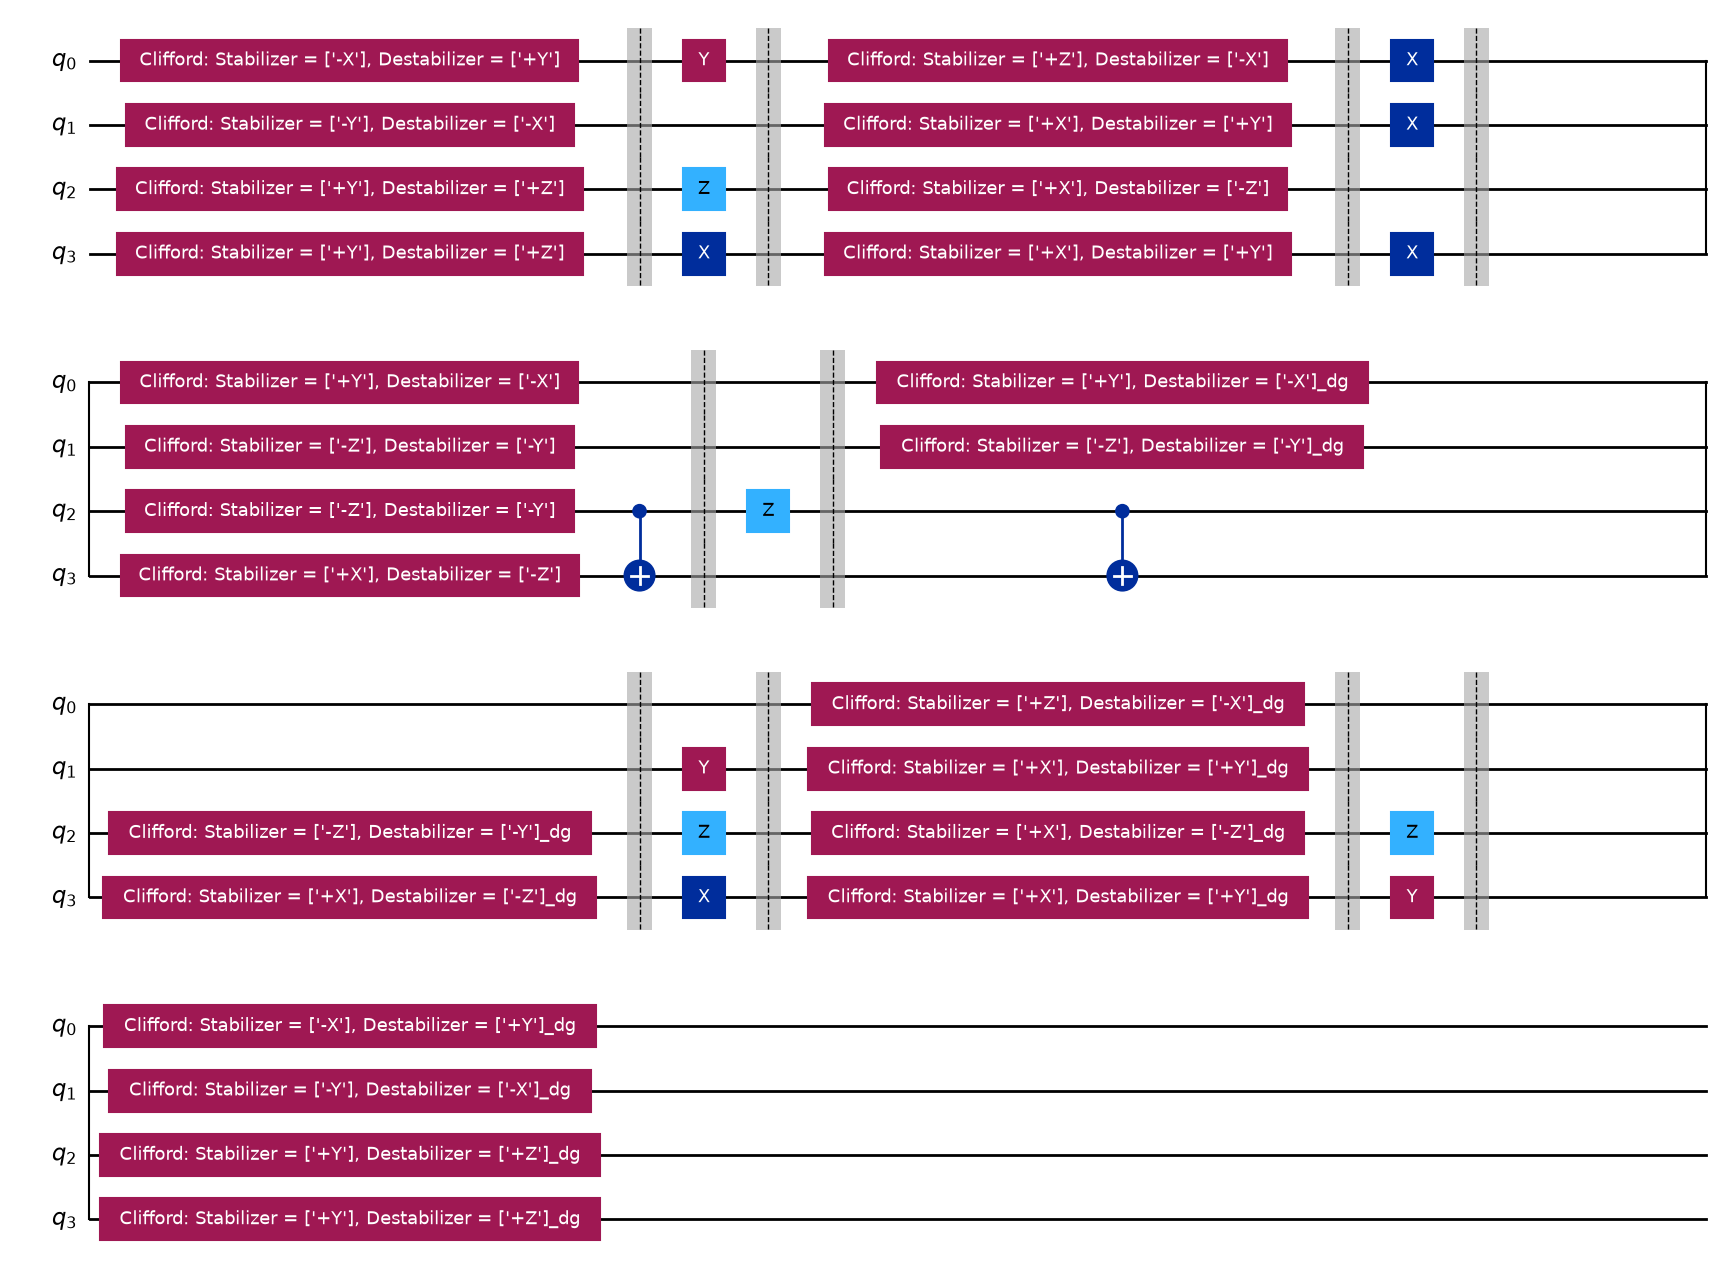

In [14]:
test_mrb = make_mrb_circuit(
    depth=4,
    seed=BASE_SEED
)

test_mrb.draw("mpl")

In [15]:
state = Statevector.from_instruction(test_mrb)

probs = state.probabilities_dict()

target_bitstring, target_probability = max(
    probs.items(),
    key=lambda item: item[1]
)

print("Ideal target:", target_bitstring)
print("Ideal probability:", target_probability)

Ideal target: 1001
Ideal probability: 0.9999999999999971


In [16]:
for depth in DEPTHS:
    test = make_mrb_circuit(
        depth=depth,
        seed=BASE_SEED + depth
    )

    state = Statevector.from_instruction(test)
    probs = state.probabilities_dict()

    target, probability = max(
        probs.items(),
        key=lambda item: item[1]
    )

    print(
        f"depth={depth:2d} | "
        f"target={target} | "
        f"P(target)={probability:.12f}"
    )

depth= 0 | target=1101 | P(target)=1.000000000000
depth= 4 | target=1010 | P(target)=1.000000000000
depth= 8 | target=1001 | P(target)=1.000000000000
depth=16 | target=0001 | P(target)=1.000000000000
depth=32 | target=1010 | P(target)=1.000000000000


In [17]:
from qiskit.quantum_info import random_clifford


def make_random_layer_v2(n_qubits, rng):
    """
    MRB-style randomized Clifford layer for a 4-qubit logical chain.

    The layer contains:
      - a random set of non-overlapping CNOTs
      - random single-qubit Clifford gates on qubits not used by CNOTs

    Logical connectivity:
        0 -- 1 -- 2 -- 3
    """

    if n_qubits != 4:
        raise ValueError("This sampler is currently designed for 4 qubits.")

    qc = QuantumCircuit(n_qubits)

    # Valid non-overlapping CNOT patterns for a 4-qubit chain.
    # CNOT is self-inverse, which is useful for MRB.
    matchings = [
        [],                         # no CNOT
        [(0, 1)],
        [(1, 2)],
        [(2, 3)],
        [(0, 1), (2, 3)]           # parallel CNOTs
    ]

    # Randomly select one entangling pattern
    matching_index = int(rng.integers(0, len(matchings)))
    selected_edges = matchings[matching_index]

    occupied_qubits = set()

    # Apply CNOTs
    for control, target in selected_edges:
        qc.cx(control, target)
        occupied_qubits.add(control)
        occupied_qubits.add(target)

    # Apply a random single-qubit Clifford to every qubit
    # that was NOT involved in a CNOT
    for q in range(n_qubits):
        if q not in occupied_qubits:
            cliff_seed = int(rng.integers(0, 2**31 - 1))
            cliff = random_clifford(1, seed=cliff_seed)

            qc.append(
                cliff.to_instruction(),
                [q]
            )

    return qc

In [18]:
def make_mrb_circuit_v2(depth, seed):
    if depth % 2 != 0:
        raise ValueError("MRB benchmark depth must be even.")

    rng = np.random.default_rng(seed)

    qc = QuantumCircuit(N_QUBITS)

    # Random initial local Clifford layer F0
    F0 = QuantumCircuit(N_QUBITS)

    for q in range(N_QUBITS):
        cliff_seed = int(rng.integers(0, 2**31 - 1))
        cliff = random_clifford(1, seed=cliff_seed)
        F0.append(cliff.to_instruction(), [q])

    qc.compose(F0, inplace=True)
    qc.barrier()

    # Initial Pauli dressing
    qc.compose(
        make_pauli_layer(N_QUBITS, rng),
        inplace=True
    )
    qc.barrier()

    # Half the benchmark depth is built forward
    half_depth = depth // 2

    forward_layers = []

    for _ in range(half_depth):

        layer = make_random_layer_v2(
            N_QUBITS,
            rng
        )

        forward_layers.append(layer)

        # Forward randomized Clifford layer
        qc.compose(layer, inplace=True)
        qc.barrier()

        # Random Pauli dressing
        qc.compose(
            make_pauli_layer(N_QUBITS, rng),
            inplace=True
        )
        qc.barrier()

    # Mirror the forward sequence
    for layer in reversed(forward_layers):

        qc.compose(
            layer.inverse(),
            inplace=True
        )
        qc.barrier()

        qc.compose(
            make_pauli_layer(N_QUBITS, rng),
            inplace=True
        )
        qc.barrier()

    # Undo the initial Clifford frame
    qc.compose(
        F0.inverse(),
        inplace=True
    )

    return qc

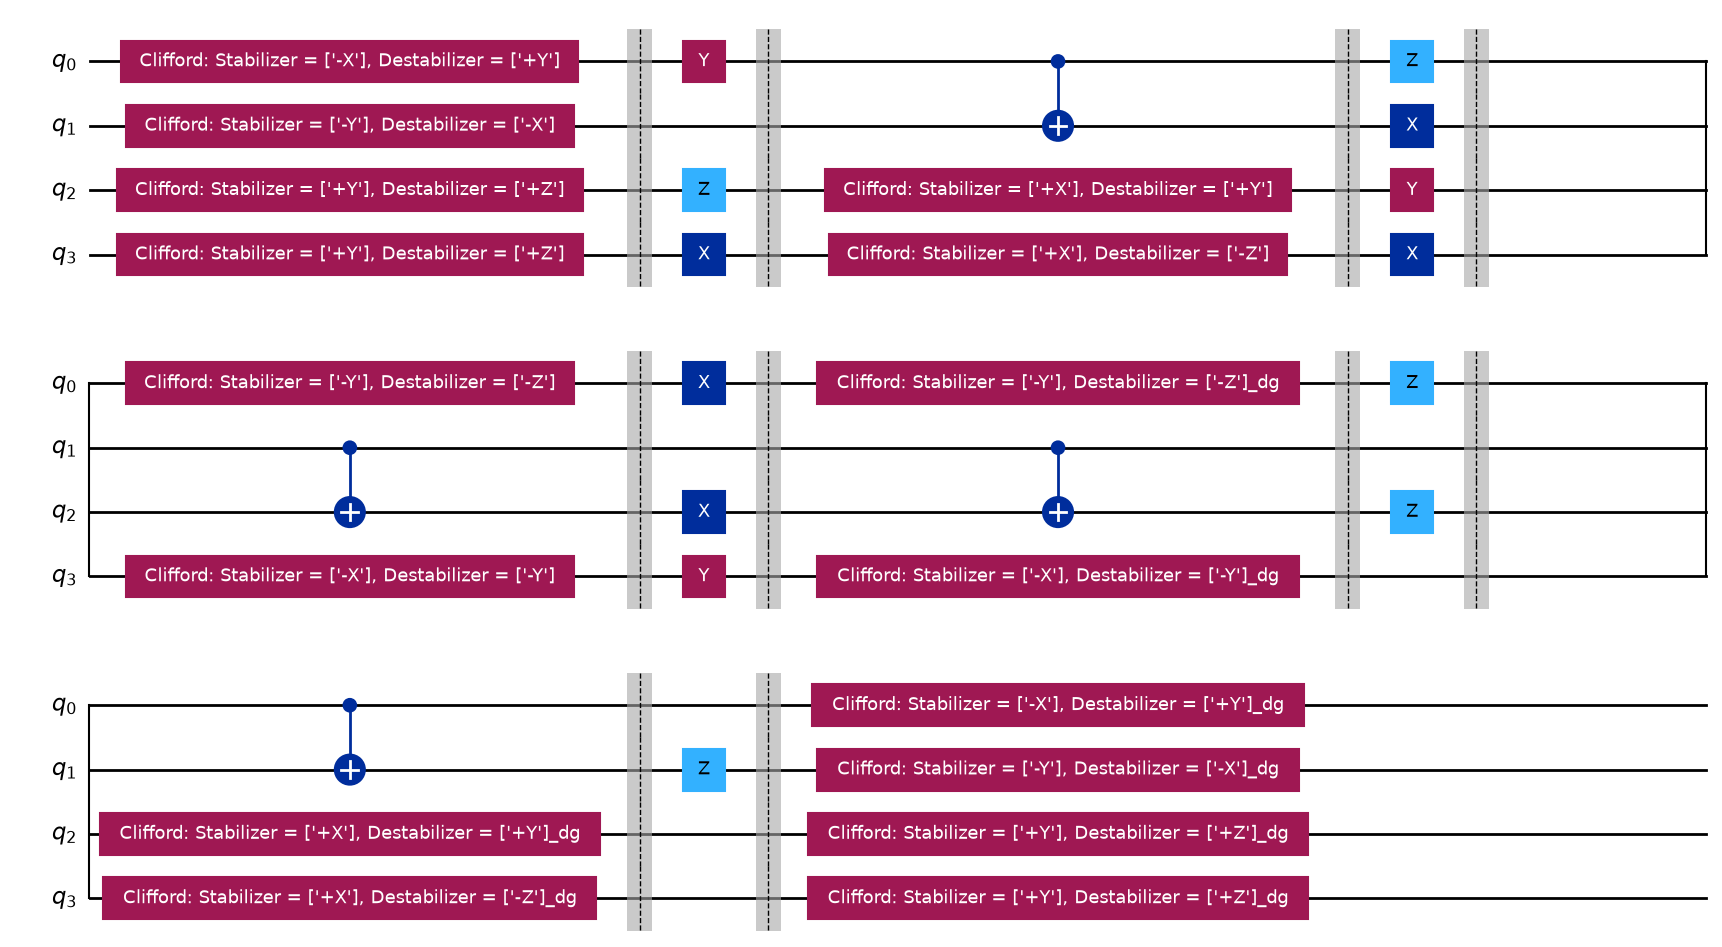

In [19]:
test_v2 = make_mrb_circuit_v2(
    depth=4,
    seed=BASE_SEED
)

test_v2.draw("mpl")

In [20]:
state = Statevector.from_instruction(test_v2)

probs = state.probabilities_dict()

target, probability = max(
    probs.items(),
    key=lambda item: item[1]
)

print("Target:", target)
print("Ideal probability:", probability)

Target: 1110
Ideal probability: 0.9999999999999976


In [21]:
MRB_DEPTHS = [0, 4, 8, 16, 32]
K = 8

mrb_records = []

for depth in MRB_DEPTHS:
    for k in range(K):

        # Deterministic/reproducible seed
        seed = BASE_SEED + depth * 100 + k

        circuit = make_mrb_circuit_v2(
            depth=depth,
            seed=seed
        )

        # Compute ideal target
        state = Statevector.from_instruction(circuit)
        probs = state.probabilities_dict()

        target, target_probability = max(
            probs.items(),
            key=lambda item: item[1]
        )

        mrb_records.append({
            "depth": depth,
            "instance": k,
            "seed": seed,
            "target": target,
            "ideal_probability": target_probability,
            "circuit": circuit
        })

In [22]:
for record in mrb_records:
    print(
        f"d={record['depth']:2d} | "
        f"k={record['instance']} | "
        f"target={record['target']} | "
        f"P={record['ideal_probability']:.12f}"
    )

d= 0 | k=0 | target=1101 | P=1.000000000000
d= 0 | k=1 | target=0011 | P=1.000000000000
d= 0 | k=2 | target=0010 | P=1.000000000000
d= 0 | k=3 | target=0110 | P=1.000000000000
d= 0 | k=4 | target=0010 | P=1.000000000000
d= 0 | k=5 | target=1100 | P=1.000000000000
d= 0 | k=6 | target=0110 | P=1.000000000000
d= 0 | k=7 | target=0111 | P=1.000000000000
d= 4 | k=0 | target=0111 | P=1.000000000000
d= 4 | k=1 | target=0101 | P=1.000000000000
d= 4 | k=2 | target=1011 | P=1.000000000000
d= 4 | k=3 | target=0100 | P=1.000000000000
d= 4 | k=4 | target=1100 | P=1.000000000000
d= 4 | k=5 | target=1101 | P=1.000000000000
d= 4 | k=6 | target=1110 | P=1.000000000000
d= 4 | k=7 | target=0101 | P=1.000000000000
d= 8 | k=0 | target=1011 | P=1.000000000000
d= 8 | k=1 | target=1110 | P=1.000000000000
d= 8 | k=2 | target=1110 | P=1.000000000000
d= 8 | k=3 | target=1101 | P=1.000000000000
d= 8 | k=4 | target=0001 | P=1.000000000000
d= 8 | k=5 | target=0011 | P=1.000000000000
d= 8 | k=6 | target=1011 | P=1.0

In [23]:
bad_circuits = [
    r for r in mrb_records
    if r["ideal_probability"] < 0.999999
]

print("Total circuits:", len(mrb_records))
print("Failed ideal-target check:", len(bad_circuits))

Total circuits: 40
Failed ideal-target check: 0


In [24]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

REGIONS = {
    "0123": [0, 1, 2, 3],
    "6789": [6, 7, 8, 9]
}

In [25]:
physical_records = []

for region_name, physical_qubits in REGIONS.items():

    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=0,
        initial_layout=physical_qubits
    )

    for record in mrb_records:

        # Copy logical circuit so original remains untouched
        measured_circuit = record["circuit"].copy()

        # Add computational-basis measurements
        measured_circuit.measure_all()

        # Map onto fixed physical region
        isa_circuit = pm.run(measured_circuit)

        physical_records.append({
            "region": region_name,
            "physical_qubits": physical_qubits,
            "depth": record["depth"],
            "instance": record["instance"],
            "seed": record["seed"],
            "target": record["target"],
            "ideal_probability": record["ideal_probability"],
            "transpiled_depth": isa_circuit.depth(),
            "operations": isa_circuit.count_ops(),
            "circuit": isa_circuit
        })

In [26]:
print("Logical circuits:", len(mrb_records))
print("Physical circuits:", len(physical_records))

Logical circuits: 40
Physical circuits: 80


In [27]:
for r in physical_records[:10]:
    print(
        f"region={r['region']} | "
        f"d={r['depth']:2d} | "
        f"k={r['instance']} | "
        f"target={r['target']} | "
        f"transpiled depth={r['transpiled_depth']} | "
        f"ops={r['operations']}"
    )

region=0123 | d= 0 | k=0 | target=1101 | transpiled depth=17 | ops=OrderedDict({'rz': 30, 'sx': 8, 'x': 6, 'measure': 4, 'barrier': 3})
region=0123 | d= 0 | k=1 | target=0011 | transpiled depth=15 | ops=OrderedDict({'rz': 25, 'x': 7, 'sx': 6, 'measure': 4, 'barrier': 3})
region=0123 | d= 0 | k=2 | target=0010 | transpiled depth=15 | ops=OrderedDict({'rz': 19, 'x': 7, 'sx': 4, 'measure': 4, 'barrier': 3})
region=0123 | d= 0 | k=3 | target=0110 | transpiled depth=10 | ops=OrderedDict({'rz': 20, 'sx': 6, 'measure': 4, 'x': 3, 'barrier': 3})
region=0123 | d= 0 | k=4 | target=0010 | transpiled depth=11 | ops=OrderedDict({'rz': 15, 'x': 8, 'sx': 4, 'measure': 4, 'barrier': 3})
region=0123 | d= 0 | k=5 | target=1100 | transpiled depth=14 | ops=OrderedDict({'rz': 24, 'x': 6, 'sx': 4, 'measure': 4, 'barrier': 3})
region=0123 | d= 0 | k=6 | target=0110 | transpiled depth=15 | ops=OrderedDict({'rz': 28, 'x': 6, 'sx': 4, 'measure': 4, 'barrier': 3})
region=0123 | d= 0 | k=7 | target=0111 | transpi

In [28]:
print("Total physical circuits:", len(physical_records))

for region_name in REGIONS:
    print(f"\nREGION {region_name}")

    for depth in MRB_DEPTHS:
        records = [
            r for r in physical_records
            if r["region"] == region_name
            and r["depth"] == depth
        ]

        depths = [r["transpiled_depth"] for r in records]

        print(
            f"MRB d={depth:2d} | "
            f"circuits={len(records)} | "
            f"physical depth min={min(depths):3d} | "
            f"mean={sum(depths)/len(depths):6.1f} | "
            f"max={max(depths):3d}"
        )

Total physical circuits: 80

REGION 0123
MRB d= 0 | circuits=8 | physical depth min= 10 | mean=  14.0 | max= 17
MRB d= 4 | circuits=8 | physical depth min= 42 | mean=  46.9 | max= 51
MRB d= 8 | circuits=8 | physical depth min= 74 | mean=  81.5 | max= 86
MRB d=16 | circuits=8 | physical depth min=145 | mean= 150.0 | max=153
MRB d=32 | circuits=8 | physical depth min=273 | mean= 279.2 | max=289

REGION 6789
MRB d= 0 | circuits=8 | physical depth min= 10 | mean=  14.0 | max= 17
MRB d= 4 | circuits=8 | physical depth min= 42 | mean=  46.9 | max= 51
MRB d= 8 | circuits=8 | physical depth min= 74 | mean=  81.5 | max= 86
MRB d=16 | circuits=8 | physical depth min=145 | mean= 150.0 | max=153
MRB d=32 | circuits=8 | physical depth min=273 | mean= 279.2 | max=289


In [29]:
# Identify native 2-qubit operations on ibm_quebec
two_q_gate_names = {
    name
    for name in backend.target.operation_names
    if getattr(
        backend.target.operation_from_name(name),
        "num_qubits",
        None
    ) == 2
}

print("Native 2-qubit gates:", two_q_gate_names)

Native 2-qubit gates: {'cz'}


In [30]:
for r in physical_records:
    r["two_qubit_gates"] = sum(
        count
        for gate_name, count in r["operations"].items()
        if gate_name in two_q_gate_names
    )

In [31]:
for region_name in REGIONS:
    print(f"\nREGION {region_name}")

    for depth in MRB_DEPTHS:
        records = [
            r for r in physical_records
            if r["region"] == region_name
            and r["depth"] == depth
        ]

        physical_depths = [
            r["transpiled_depth"]
            for r in records
        ]

        twoq_counts = [
            r["two_qubit_gates"]
            for r in records
        ]

        print(
            f"d={depth:2d} | "
            f"circuits={len(records)} | "
            f"depth mean={sum(physical_depths)/len(physical_depths):6.1f} | "
            f"2Q mean={sum(twoq_counts)/len(twoq_counts):6.1f}"
        )


REGION 0123
d= 0 | circuits=8 | depth mean=  14.0 | 2Q mean=   0.0
d= 4 | circuits=8 | depth mean=  46.9 | 2Q mean=   3.8
d= 8 | circuits=8 | depth mean=  81.5 | 2Q mean=   8.8
d=16 | circuits=8 | depth mean= 150.0 | 2Q mean=  19.0
d=32 | circuits=8 | depth mean= 279.2 | 2Q mean=  32.2

REGION 6789
d= 0 | circuits=8 | depth mean=  14.0 | 2Q mean=   0.0
d= 4 | circuits=8 | depth mean=  46.9 | 2Q mean=   3.8
d= 8 | circuits=8 | depth mean=  81.5 | 2Q mean=   8.8
d=16 | circuits=8 | depth mean= 150.0 | 2Q mean=  19.0
d=32 | circuits=8 | depth mean= 279.2 | 2Q mean=  32.2


In [32]:
for depth in MRB_DEPTHS:
    for k in range(K):

        a = next(
            r for r in physical_records
            if r["region"] == "0123"
            and r["depth"] == depth
            and r["instance"] == k
        )

        b = next(
            r for r in physical_records
            if r["region"] == "6789"
            and r["depth"] == depth
            and r["instance"] == k
        )

        assert a["seed"] == b["seed"]
        assert a["target"] == b["target"]

print("Region-pair consistency check passed.")

Region-pair consistency check passed.


In [33]:
status = backend.status()

print("Backend:", backend.name)
print("Operational:", status.operational)
print("Pending jobs:", status.pending_jobs)
print("Status message:", status.status_msg)

Backend: ibm_quebec
Operational: True
Pending jobs: 70
Status message: active


In [34]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Preserve the exact ordering used in physical_records
submission_circuits = [
    record["circuit"]
    for record in physical_records
]

print("Circuits about to submit:", len(submission_circuits))

sampler = Sampler(mode=backend)

job = sampler.run(
    submission_circuits,
    shots=256
)

print("Job submitted.")
print("Job ID:", job.job_id())
print("Status:", job.status())

Circuits about to submit: 80


C:\Users\ahmad\AppData\Local\Temp\ipykernel_50076\1567128120.py:11: DeprecationWarning: The SamplerV2 class is deprecated as of qiskit-ibm-runtime 0.50.0 and will be removed no sooner than 3 months after the release date. `qiskit_ibm_runtime.executor_sampler.Sampler` provides a new Sampler implementation that runs all the pre- and post-processing in the client side. The top-level `qiskit_ibm_runtime.Sampler` import will be updated to point to the client-side sampler in an upcoming release, with the legacy Sampler being available until the deprecation is completed.
  sampler = Sampler(mode=backend)


Job submitted.
Job ID: db1kd9ivog1s73fi8r10
Status: QUEUED


In [35]:
from pathlib import Path

job_id = job.job_id()

Path("ibm_job_id.txt").write_text(
    job_id,
    encoding="utf-8"
)

print("Saved job ID:", job_id)

Saved job ID: db1kd9ivog1s73fi8r10


In [36]:
import json

manifest = []

for i, r in enumerate(physical_records):
    manifest.append({
        "result_index": i,
        "region": r["region"],
        "physical_qubits": list(r["physical_qubits"]),
        "depth": int(r["depth"]),
        "instance": int(r["instance"]),
        "seed": int(r["seed"]),
        "target": r["target"],
        "ideal_probability": float(r["ideal_probability"]),
        "transpiled_depth": int(r["transpiled_depth"]),
        "two_qubit_gates": int(r["two_qubit_gates"]),
    })

Path("mrb_manifest.json").write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8"
)

print("Saved", len(manifest), "circuit records.")

Saved 80 circuit records.


In [37]:
status = backend.status()

print("Backend:", backend.name)
print("Operational:", status.operational)
print("Pending jobs:", status.pending_jobs)
print("Status message:", status.status_msg)

Backend: ibm_quebec
Operational: True
Pending jobs: 48
Status message: active


In [38]:
status = backend.status()

print("Backend:", backend.name)
print("Operational:", status.operational)
print("Pending jobs:", status.pending_jobs)
print("Status message:", status.status_msg)

Backend: ibm_quebec
Operational: True
Pending jobs: 19
Status message: active


In [39]:
service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=token
)

saved_job_id = Path("ibm_job_id.txt").read_text().strip()

job = service.job(saved_job_id)

print("Job ID:", job.job_id())
print("Status:", job.status())

qiskit_runtime_service._discover_account:WARNING:2026-10-05 09:25:08,178: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-10-05 09:25:15,855: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon UOttawa Oct 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.


Job ID: db1kd9ivog1s73fi8r10
Status: DONE


In [40]:
result = job.result()

print("Results retrieved.")
print("Number of circuit results:", len(result))

Results retrieved.
Number of circuit results: 80


In [41]:

manifest = json.loads(
    Path("mrb_manifest.json").read_text(
        encoding="utf-8"
    )
)

experiment_results = []

for i, meta in enumerate(manifest):

    pub_result = result[i]

    counts = pub_result.data.meas.get_counts()

    total_shots = sum(counts.values())

    target = meta["target"]

    target_count = counts.get(target, 0)

    success_probability = (
        target_count / total_shots
    )

    experiment_results.append({
        **meta,
        "shots": total_shots,
        "target_count": target_count,
        "success_probability": success_probability,
        "counts": counts
    })

print("Processed:", len(experiment_results))

Processed: 80


In [42]:
for region in ["0123", "6789"]:

    print(f"\nREGION {region}")

    for depth in [0, 4, 8, 16, 32]:

        values = [
            r["success_probability"]
            for r in experiment_results
            if r["region"] == region
            and r["depth"] == depth
        ]

        print(
            f"d={depth:2d} | "
            f"mean success={np.mean(values):.4f} | "
            f"std={np.std(values):.4f}"
        )


REGION 0123
d= 0 | mean success=0.9683 | std=0.0120
d= 4 | mean success=0.9370 | std=0.0116
d= 8 | mean success=0.9287 | std=0.0222
d=16 | mean success=0.8867 | std=0.0220
d=32 | mean success=0.8071 | std=0.0431

REGION 6789
d= 0 | mean success=0.8691 | std=0.0348
d= 4 | mean success=0.5957 | std=0.2196
d= 8 | mean success=0.6353 | std=0.1181
d=16 | mean success=0.3833 | std=0.2177
d=32 | mean success=0.1279 | std=0.0783


In [43]:
def hamming_distance(a, b):
    a = a.replace(" ", "")
    b = b.replace(" ", "")

    if len(a) != len(b):
        raise ValueError(
            f"Bitstrings must have same length: {a}, {b}"
        )

    return sum(
        bit_a != bit_b
        for bit_a, bit_b in zip(a, b)
    )

In [44]:
print(hamming_distance("1101", "1101"))  # 0
print(hamming_distance("1101", "1001"))  # 1
print(hamming_distance("1101", "0001"))  # 2

0
1
2


In [45]:
def get_hamming_distribution(counts, target, n_qubits=4):

    target = target.replace(" ", "").zfill(n_qubits)

    h = [0.0] * (n_qubits + 1)

    total_shots = sum(counts.values())

    for bitstring, count in counts.items():

        bitstring = (
            bitstring
            .replace(" ", "")
            .zfill(n_qubits)
        )

        k = hamming_distance(
            bitstring,
            target
        )

        h[k] += count / total_shots

    return h

In [46]:
example = experiment_results[0]

h = get_hamming_distribution(
    counts=example["counts"],
    target=example["target"],
    n_qubits=4
)

print("Target:", example["target"])

for k, probability in enumerate(h):
    print(
        f"Hamming distance {k}: "
        f"{probability:.4f}"
    )

print("Sum:", sum(h))

Target: 1101
Hamming distance 0: 0.9844
Hamming distance 1: 0.0156
Hamming distance 2: 0.0000
Hamming distance 3: 0.0000
Hamming distance 4: 0.0000
Sum: 1.0


In [47]:
print("h[0]:", h[0])
print(
    "Success probability:",
    example["success_probability"]
)

h[0]: 0.984375
Success probability: 0.984375


In [48]:
def effective_polarization(
    counts,
    target,
    n_qubits=4
):

    h = get_hamming_distribution(
        counts=counts,
        target=target,
        n_qubits=n_qubits
    )

    H = sum(
        (-0.5)**k * h[k]
        for k in range(n_qubits + 1)
    )

    S = (
        (4**n_qubits)
        / (4**n_qubits - 1)
        * H
        - 1 / (4**n_qubits - 1)
    )

    return S, h

In [49]:
for record in experiment_results:

    S, h = effective_polarization(
        counts=record["counts"],
        target=record["target"],
        n_qubits=4
    )

    record["polarization"] = S
    record["hamming_distribution"] = h

print(
    "Processed:",
    len(experiment_results),
    "circuits"
)

Processed: 80 circuits


In [50]:
r = experiment_results[0]

print("Region:", r["region"])
print("Depth:", r["depth"])
print("Instance:", r["instance"])
print("Target:", r["target"])
print(
    "Success probability:",
    round(r["success_probability"], 4)
)
print(
    "Effective polarization:",
    round(r["polarization"], 4)
)

print("\nHamming distribution:")

for k, value in enumerate(
    r["hamming_distribution"]
):
    print(
        f"k={k}: {value:.4f}"
    )

Region: 0123
Depth: 0
Instance: 0
Target: 1101
Success probability: 0.9844
Effective polarization: 0.9765

Hamming distribution:
k=0: 0.9844
k=1: 0.0156
k=2: 0.0000
k=3: 0.0000
k=4: 0.0000


In [51]:
for region in ["0123", "6789"]:

    print(f"\nREGION {region}")

    for depth in MRB_DEPTHS:

        values = [
            r["polarization"]
            for r in experiment_results
            if r["region"] == region
            and r["depth"] == depth
        ]

        print(
            f"d={depth:2d} | "
            f"mean S={np.mean(values):.4f} | "
            f"std={np.std(values):.4f}"
        )


REGION 0123
d= 0 | mean S=0.9526 | std=0.0180
d= 4 | mean S=0.9153 | std=0.0169
d= 8 | mean S=0.9066 | std=0.0280
d=16 | mean S=0.8577 | std=0.0249
d=32 | mean S=0.7669 | std=0.0542

REGION 6789
d= 0 | mean S=0.8083 | std=0.0542
d= 4 | mean S=0.4646 | std=0.2881
d= 8 | mean S=0.5215 | std=0.1789
d=16 | mean S=0.2770 | std=0.2513
d=32 | mean S=0.0586 | std=0.0780


In [52]:
from scipy.optimize import curve_fit
import numpy as np

def decay_model(d, A, p):
    return A * (p ** d)

fit_results = {}

for region in ["0123", "6789"]:

    depths = []
    mean_S = []

    for depth in MRB_DEPTHS:

        values = [
            r["polarization"]
            for r in experiment_results
            if r["region"] == region
            and r["depth"] == depth
        ]

        depths.append(depth)
        mean_S.append(np.mean(values))

    depths = np.array(depths, dtype=float)
    mean_S = np.array(mean_S, dtype=float)

    popt, pcov = curve_fit(
        decay_model,
        depths,
        mean_S,
        p0=[mean_S[0], 0.99],
        bounds=([0, 0], [1.5, 1])
    )

    A, p = popt

    r_omega = (255 / 256) * (1 - p)

    fit_results[region] = {
        "A": A,
        "p": p,
        "r_omega": r_omega,
        "depths": depths,
        "mean_S": mean_S
    }

    print(f"\nREGION {region}")
    print(f"A       = {A:.6f}")
    print(f"p       = {p:.6f}")
    print(f"r_omega = {r_omega:.6f}")


REGION 0123
A       = 0.949794
p       = 0.993418
r_omega = 0.006556

REGION 6789
A       = 0.766033
p       = 0.934157
r_omega = 0.065586


In [53]:
import matplotlib.pyplot as plt

for region in ["0123", "6789"]:

    result = fit_results[region]

    depths = result["depths"]
    mean_S = result["mean_S"]

    d_fit = np.linspace(
        min(depths),
        max(depths),
        200
    )

    S_fit = decay_model(
        d_fit,
        result["A"],
        result["p"]
    )

In [54]:
def decay_model(d, A, p):
    return A * (p ** d)


def bootstrap_mrb_region(
    experiment_results,
    region,
    depths,
    n_bootstrap=5000,
    seed=42
):
    rng = np.random.default_rng(seed)

    # Collect the 8 polarization values at each depth
    data_by_depth = {}

    for depth in depths:
        values = np.array([
            r["polarization"]
            for r in experiment_results
            if r["region"] == region
            and r["depth"] == depth
        ])

        data_by_depth[depth] = values

    bootstrap_p = []
    bootstrap_r = []
    bootstrap_A = []

    for _ in range(n_bootstrap):

        boot_means = []

        for depth in depths:
            values = data_by_depth[depth]

            # Resample the K circuits WITH replacement
            resampled = rng.choice(
                values,
                size=len(values),
                replace=True
            )

            boot_means.append(
                np.mean(resampled)
            )

        boot_means = np.array(boot_means)

        try:
            popt, _ = curve_fit(
                decay_model,
                np.array(depths, dtype=float),
                boot_means,
                p0=[boot_means[0], 0.99],
                bounds=([0, 0], [1.5, 1]),
                maxfev=10000
            )

            A, p = popt

            r_omega = (
                (255 / 256)
                * (1 - p)
            )

            bootstrap_A.append(A)
            bootstrap_p.append(p)
            bootstrap_r.append(r_omega)

        except RuntimeError:
            # Skip rare failed fits
            continue

    return {
        "A": np.array(bootstrap_A),
        "p": np.array(bootstrap_p),
        "r_omega": np.array(bootstrap_r)
    }

In [55]:
bootstrap_results = {}

for region in ["0123", "6789"]:

    boot = bootstrap_mrb_region(
        experiment_results,
        region,
        MRB_DEPTHS,
        n_bootstrap=5000,
        seed=42
    )

    bootstrap_results[region] = boot

    r_values = boot["r_omega"]
    p_values = boot["p"]

    print(f"\nREGION {region}")

    print(
        f"p = "
        f"{np.mean(p_values):.6f} "
        f"± {np.std(p_values, ddof=1):.6f}"
    )

    print(
        f"r_omega = "
        f"{np.mean(r_values):.6f} "
        f"± {np.std(r_values, ddof=1):.6f}"
    )

    print(
        "95% CI for r_omega:",
        f"[{np.percentile(r_values, 2.5):.6f}, "
        f"{np.percentile(r_values, 97.5):.6f}]"
    )


REGION 0123
p = 0.993412 ± 0.000751
r_omega = 0.006562 ± 0.000748
95% CI for r_omega: [0.005040, 0.007966]

REGION 6789
p = 0.932833 ± 0.011745
r_omega = 0.066905 ± 0.011699
95% CI for r_omega: [0.048018, 0.092446]


In [1]:
status = backend.status()

print("Backend:", backend.name)
print("Operational:", status.operational)
print("Pending jobs:", status.pending_jobs)
print("Status message:", status.status_msg)

NameError: name 'backend' is not defined

In [2]:
token = os.getenv("IBM_QUANTUM_TOKEN")

service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=token
)

backend = service.backend("ibm_quebec")

print("Connected to:", backend.name)

NameError: name 'os' is not defined

In [3]:
import os
from qiskit_ibm_runtime import QiskitRuntimeService

token = os.getenv("IBM_QUANTUM_TOKEN")

service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=token
)

backend = service.backend("ibm_quebec")

print("Connected to:", backend.name)

AccountNotFoundError: "Unable to find account. Please make sure an account with the channel name 'ibm_cloud' is saved."

In [4]:
import os

token = os.getenv("IBM_QUANTUM_TOKEN")

print("Token found:", token is not None)

Token found: False


In [1]:
import os
from qiskit_ibm_runtime import QiskitRuntimeService

token = os.getenv("IBM_QUANTUM_TOKEN")

print("Token found:", token is not None)

service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=token
)

backend = service.backend("ibm_quebec")

print("Connected to:", backend.name)

qiskit_runtime_service._discover_account:WARNING:2026-10-06 21:01:32,489: Loading account with the given token. A saved account will not be used.


Token found: True


qiskit_runtime_service.__init__:WARNING:2026-10-06 21:01:39,976: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon UOttawa Oct 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-10-06 21:01:39,977: Using instance: Hackathon UOttawa Oct 2026, plan: on-prem


Connected to: ibm_quebec


In [2]:
status = backend.status()

print("Backend:", backend.name)
print("Operational:", status.operational)
print("Pending jobs:", status.pending_jobs)
print("Status message:", status.status_msg)

Backend: ibm_quebec
Operational: True
Pending jobs: 0
Status message: active


In [3]:
import h5py
import numpy as np

FILE = "http.mat"

with h5py.File(FILE, "r") as f:
    X = np.array(f["X"]).T
    y = np.array(f["y"]).reshape(-1).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    print(
        f"class {label}: {count} "
        f"({count / len(y) * 100:.4f}%)"
    )

ModuleNotFoundError: No module named 'h5py'

In [4]:
%pip install h5py

   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/3.2 MB ? eta -:--:--
   --------- ------------------------------ 0.8/3.2 MB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 3.2/3.2 MB 11.0 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
# =========================
# Standard library
# =========================


from pathlib import Path


# =========================
# Numerical / scientific
# =========================

import numpy as np
import pandas as pd

from scipy.optimize import curve_fit


# =========================
# Machine learning
# =========================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve
)


# =========================
# Plotting
# =========================

import matplotlib.pyplot as plt


# =========================
# Qiskit
# =========================

from qiskit import QuantumCircuit
from qiskit.quantum_info import (
    Statevector,
    random_clifford
)

from qiskit.transpiler.preset_passmanagers import (
    generate_preset_pass_manager
)


# =========================
# IBM Runtime
# =========================

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2,
    EstimatorV2
)

In [6]:
from qiskit.circuit import Parameter, ParameterVector

from qiskit_machine_learning.optimizers import (
    COBYLA,
    SPSA
)

In [7]:
token = os.getenv("IBM_QUANTUM_TOKEN")

print("Token found:", token is not None)

service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=token
)

backend = service.backend("ibm_quebec")

print("Connected to:", backend.name)

qiskit_runtime_service._discover_account:WARNING:2026-10-06 21:42:19,863: Loading account with the given token. A saved account will not be used.


Token found: True


qiskit_runtime_service.__init__:WARNING:2026-10-06 21:42:26,713: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon UOttawa Oct 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-10-06 21:42:26,713: Using instance: Hackathon UOttawa Oct 2026, plan: on-prem


Connected to: ibm_quebec


In [8]:
import qiskit
import qiskit_machine_learning
import qiskit_ibm_runtime
import sklearn
import scipy

print("Qiskit:", qiskit.__version__)
print("Qiskit ML:", qiskit_machine_learning.__version__)
print("Qiskit Runtime:", qiskit_ibm_runtime.__version__)
print("Scikit-learn:", sklearn.__version__)
print("SciPy:", scipy.__version__)

Qiskit: 2.5.2
Qiskit ML: 0.9.1
Qiskit Runtime: 0.50.0
Scikit-learn: 1.9.1
SciPy: 1.18.1


In [9]:
FILE = "http.mat"

with h5py.File(FILE, "r") as f:
    X = np.array(f["X"]).T
    y = np.array(f["y"]).reshape(-1).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    print(
        f"class {label}: {count} "
        f"({count / len(y) * 100:.4f}%)"
    )

NameError: name 'h5py' is not defined

In [1]:
FILE = "http.mat"

with h5py.File(FILE, "r") as f:
    X = np.array(f["X"]).T
    y = np.array(f["y"]).reshape(-1).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

NameError: name 'h5py' is not defined

In [2]:
import h5py
import numpy as np

In [3]:
FILE = "http.mat"

with h5py.File(FILE, "r") as f:
    X = np.array(f["X"]).T
    y = np.array(f["y"]).reshape(-1).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'http.mat', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [5]:
import sys
import subprocess
from pathlib import Path

# Install into THIS notebook's Python environment
subprocess.check_call([
    sys.executable,
    "-m",
    "pip",
    "install",
    "h5py"
])

# Imports
import h5py
import numpy as np

print("Python:", sys.executable)
print("h5py version:", h5py.__version__)

# Check dataset location
FILE = Path("http.mat")

print("Current folder:", Path.cwd())
print("http.mat found:", FILE.exists())

if not FILE.exists():
    raise FileNotFoundError(
        f"http.mat is not in {Path.cwd()}"
    )

# Load dataset
with h5py.File(FILE, "r") as f:
    print("MAT keys:", list(f.keys()))

    X = np.array(f["X"]).T
    y = np.array(f["y"]).reshape(-1).astype(int)

print("X shape:", X.shape)
print("y shape:", y.shape)

unique, counts = np.unique(y, return_counts=True)

for label, count in zip(unique, counts):
    print(
        f"class {label}: {count} "
        f"({count / len(y) * 100:.4f}%)"
    )

Python: c:\Users\ahmad\qff26\Scripts\python.exe
h5py version: 3.16.0
Current folder: c:\Users\ahmad\qiskit-fall-fest\Team_03_QFF2026_uottawa
http.mat found: True
MAT keys: ['X', 'y']
X shape: (567498, 3)
y shape: (567498,)
class 0: 565287 (99.6104%)
class 1: 2211 (0.3896%)


In [6]:
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42

indices = np.arange(len(y))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_SEED
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=y[temp_idx],
    random_state=RANDOM_SEED
)

for name, idx in [
    ("TRAIN", train_idx),
    ("VALIDATION", val_idx),
    ("TEST", test_idx)
]:
    print(
        f"{name:10s} | "
        f"n={len(idx):6d} | "
        f"anomalies={y[idx].sum():4d} | "
        f"rate={np.mean(y[idx]) * 100:.4f}%"
    )

TRAIN      | n=397248 | anomalies=1548 | rate=0.3897%
VALIDATION | n= 85125 | anomalies= 332 | rate=0.3900%
TEST       | n= 85125 | anomalies= 331 | rate=0.3888%


In [7]:
normal_train_idx = train_idx[
    y[train_idx] == 0
]

rng = np.random.default_rng(RANDOM_SEED)

N_QML_TRAIN = 2000

qml_train_idx = rng.choice(
    normal_train_idx,
    size=N_QML_TRAIN,
    replace=False
)

X_train = X[qml_train_idx]

print("QML training shape:", X_train.shape)
print("Training anomalies:", y[qml_train_idx].sum())

QML training shape: (2000, 3)
Training anomalies: 0


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit ONLY on normal training data
scaler.fit(X_train)

X_train_z = scaler.transform(X_train)
X_val_z   = scaler.transform(X[val_idx])
X_test_z  = scaler.transform(X[test_idx])

print("Training means:", X_train_z.mean(axis=0))
print("Training stds: ", X_train_z.std(axis=0))

Training means: [-8.12645784e-15  9.29054056e-15  5.49660317e-15]
Training stds:  [1. 1. 1.]


In [9]:
def to_quantum_angles(X_z):
    X_clipped = np.clip(X_z, -3.0, 3.0)
    return X_clipped * (np.pi / 3.0)

X_train_q = to_quantum_angles(X_train_z)
X_val_q   = to_quantum_angles(X_val_z)
X_test_q  = to_quantum_angles(X_test_z)

print("Train angle range:", X_train_q.min(), X_train_q.max())
print("Val angle range:  ", X_val_q.min(), X_val_q.max())
print("Test angle range: ", X_test_q.min(), X_test_q.max())

Train angle range: -3.141592653589793 3.141592653589793
Val angle range:   -3.141592653589793 3.141592653589793
Test angle range:  -3.141592653589793 3.141592653589793


In [10]:
y_train = np.zeros(len(X_train_q), dtype=int)
y_val   = y[val_idx]
y_test  = y[test_idx]

print("Train anomalies:", y_train.sum())
print("Validation anomalies:", y_val.sum())
print("Test anomalies:", y_test.sum())

Train anomalies: 0
Validation anomalies: 332
Test anomalies: 331


In [16]:
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import SparsePauliOp

N_QUBITS = 4
N_FEATURES = 3


def build_vad_circuit(L):
    """
    Variable-depth variational anomaly detector.

    L = number of trainable variational layers.
    """

    if L not in [1, 2, 3, 4, 5]:
        raise ValueError("L must be one of {1,2,3,4,5}")

    # Classical cybersecurity features
    x = ParameterVector("x", N_FEATURES)

    # 2 trainable rotations per qubit per layer
    theta = ParameterVector(
        "theta",
        2 * N_QUBITS * L
    )

    qc = QuantumCircuit(N_QUBITS)

    # -------------------------
    # Feature encoding
    # -------------------------

    # -------------------------
    # Feature encoding
    # -------------------------

    # Encode the 3 cybersecurity features
    qc.ry(x[0], 0)
    qc.ry(x[1], 1)
    qc.ry(x[2], 2)

    # Re-upload the features onto the readout qubit
    qc.ry(x[0], 3)
    qc.rz(x[1], 3)
    qc.ry(x[2], 3)

    qc.barrier()

    # -------------------------
    # Variational layers
    # -------------------------

    parameter_index = 0

    for layer in range(L):

        # Trainable local rotations
        for q in range(N_QUBITS):

            qc.ry(
                theta[parameter_index],
                q
            )
            parameter_index += 1

            qc.rz(
                theta[parameter_index],
                q
            )
            parameter_index += 1

        # Entangling chain
        qc.cx(0, 1)
        qc.cx(1, 2)
        qc.cx(2, 3)

        qc.barrier()

    return qc, x, theta

In [12]:
qc_L1, x_L1, theta_L1 = build_vad_circuit(1)

print("Feature parameters:", len(x_L1))
print("Trainable parameters:", len(theta_L1))
print("Circuit depth:", qc_L1.depth())

print(qc_L1.draw("text"))

Feature parameters: 3
Trainable parameters: 8
Circuit depth: 6
     ┌──────────┐ ░ ┌──────────────┐┌──────────────┐                ░ 
q_0: ┤ Ry(x[0]) ├─░─┤ Ry(theta[0]) ├┤ Rz(theta[1]) ├──■─────────────░─
     ├──────────┤ ░ ├──────────────┤├──────────────┤┌─┴─┐           ░ 
q_1: ┤ Ry(x[1]) ├─░─┤ Ry(theta[2]) ├┤ Rz(theta[3]) ├┤ X ├──■────────░─
     ├──────────┤ ░ ├──────────────┤├──────────────┤└───┘┌─┴─┐      ░ 
q_2: ┤ Ry(x[2]) ├─░─┤ Ry(theta[4]) ├┤ Rz(theta[5]) ├─────┤ X ├──■───░─
     └──────────┘ ░ ├──────────────┤├──────────────┤     └───┘┌─┴─┐ ░ 
q_3: ─────────────░─┤ Ry(theta[6]) ├┤ Rz(theta[7]) ├──────────┤ X ├─░─
                  ░ └──────────────┘└──────────────┘          └───┘ ░ 


In [13]:
READOUT = SparsePauliOp.from_list([
    ("ZIII", 1.0)
])

In [14]:
for L in [1, 2, 3, 4, 5]:

    qc, x, theta = build_vad_circuit(L)

    print(
        f"L={L} | "
        f"features={len(x)} | "
        f"trainable={len(theta)} | "
        f"circuit depth={qc.depth()}"
    )

L=1 | features=3 | trainable=8 | circuit depth=6
L=2 | features=3 | trainable=16 | circuit depth=11
L=3 | features=3 | trainable=24 | circuit depth=16
L=4 | features=3 | trainable=32 | circuit depth=21
L=5 | features=3 | trainable=40 | circuit depth=26


In [17]:
qc_L1, x_L1, theta_L1 = build_vad_circuit(1)

print(qc_L1.draw("text"))

     ┌──────────┐                         ░ ┌──────────────┐┌──────────────┐»
q_0: ┤ Ry(x[0]) ├─────────────────────────░─┤ Ry(theta[0]) ├┤ Rz(theta[1]) ├»
     ├──────────┤                         ░ ├──────────────┤├──────────────┤»
q_1: ┤ Ry(x[1]) ├─────────────────────────░─┤ Ry(theta[2]) ├┤ Rz(theta[3]) ├»
     ├──────────┤                         ░ ├──────────────┤├──────────────┤»
q_2: ┤ Ry(x[2]) ├─────────────────────────░─┤ Ry(theta[4]) ├┤ Rz(theta[5]) ├»
     ├──────────┤┌──────────┐┌──────────┐ ░ ├──────────────┤├──────────────┤»
q_3: ┤ Ry(x[0]) ├┤ Rz(x[1]) ├┤ Ry(x[2]) ├─░─┤ Ry(theta[6]) ├┤ Rz(theta[7]) ├»
     └──────────┘└──────────┘└──────────┘ ░ └──────────────┘└──────────────┘»
«                     ░ 
«q_0: ──■─────────────░─
«     ┌─┴─┐           ░ 
«q_1: ┤ X ├──■────────░─
«     └───┘┌─┴─┐      ░ 
«q_2: ─────┤ X ├──■───░─
«          └───┘┌─┴─┐ ░ 
«q_3: ──────────┤ X ├─░─
«               └───┘ ░ 


In [18]:
status = backend.status()

print("Backend:", backend.name)
print("Operational:", status.operational)
print("Pending jobs:", status.pending_jobs)
print("Status message:", status.status_msg)

NameError: name 'backend' is not defined

In [19]:
import os
from qiskit_ibm_runtime import QiskitRuntimeService

token = os.getenv("IBM_QUANTUM_TOKEN")

print("Token found:", token is not None)

service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=token
)

backend = service.backend("ibm_quebec")

print("Connected to:", backend.name)

qiskit_runtime_service._discover_account:WARNING:2026-10-06 22:02:24,033: Loading account with the given token. A saved account will not be used.


Token found: True


qiskit_runtime_service.__init__:WARNING:2026-10-06 22:02:31,292: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon UOttawa Oct 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-10-06 22:02:31,292: Using instance: Hackathon UOttawa Oct 2026, plan: on-prem


Connected to: ibm_quebec


In [20]:
status = backend.status()

print("Backend:", backend.name)
print("Operational:", status.operational)
print("Pending jobs:", status.pending_jobs)
print("Status message:", status.status_msg)

Backend: ibm_quebec
Operational: True
Pending jobs: 5
Status message: active


In [21]:
from qiskit import ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler

REGIONS = {
    "0123": [0, 1, 2, 3],
    "6789": [6, 7, 8, 9]
}

In [22]:
def prepare_vad_template(L, region_name):

    qc, x, theta = build_vad_circuit(L)

    # One classical bit: only measure the anomaly/readout qubit
    readout = ClassicalRegister(1, "readout")
    qc.add_register(readout)

    qc.measure(3, readout[0])

    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1,
        initial_layout=REGIONS[region_name]
    )

    isa_circuit = pm.run(qc)

    return isa_circuit, x, theta

In [23]:
isa_L1_0123, x_L1, theta_L1 = prepare_vad_template(
    L=1,
    region_name="0123"
)

print("Trainable parameters:", len(theta_L1))
print("Compiled depth:", isa_L1_0123.depth())
print("Operations:", isa_L1_0123.count_ops())

Trainable parameters: 8
Compiled depth: 30
Operations: OrderedDict({'rz': 35, 'sx': 24, 'cz': 3, 'barrier': 2, 'measure': 1})


In [24]:
def score_batch(
    theta_values,
    X_batch,
    L,
    region_name,
    shots=256
):

    isa_circuit, x_params, theta_params = prepare_vad_template(
        L=L,
        region_name=region_name
    )

    theta_values = np.asarray(theta_values)

    expected_theta = 2 * N_QUBITS * L

    if len(theta_values) != expected_theta:
        raise ValueError(
            f"L={L} requires {expected_theta} theta values, "
            f"but received {len(theta_values)}."
        )

    bound_circuits = []

    for sample in X_batch:

        assignments = {}

        # Bind cybersecurity features
        for i in range(N_FEATURES):
            assignments[x_params[i]] = float(sample[i])

        # Bind trainable QML parameters
        for i in range(len(theta_params)):
            assignments[theta_params[i]] = float(theta_values[i])

        bound = isa_circuit.assign_parameters(
            assignments,
            inplace=False
        )

        bound_circuits.append(bound)

    sampler = Sampler(
        mode=backend
    )

    job = sampler.run(
        bound_circuits,
        shots=shots
    )

    print("Job ID:", job.job_id())

    result = job.result()

    scores = []

    for pub_result in result:

        counts = pub_result.data.readout.get_counts()

        total = sum(counts.values())

        p_one = counts.get("1", 0) / total

        scores.append(p_one)

    return np.array(scores)

In [25]:
rng = np.random.default_rng(42)

theta_init_L1 = rng.normal(
    loc=0.0,
    scale=0.1,
    size=8
)

print(theta_init_L1)

[ 0.03047171 -0.10399841  0.07504512  0.09405647 -0.19510352 -0.13021795
  0.01278404 -0.03162426]


In [26]:
L = 1
REGION = "0123"

isa_L1, x_params_L1, theta_params_L1 = prepare_vad_template(
    L=L,
    region_name=REGION
)

print("Compiled L=1 template")
print("Trainable parameters:", len(theta_params_L1))

Compiled L=1 template
Trainable parameters: 8


In [27]:
DEPTHS = [1, 2, 3, 4, 5]
REGION = "0123"

templates = {
    1: {
        "circuit": isa_L1,
        "x_params": x_params_L1,
        "theta_params": theta_params_L1
    }
}

for L in [2, 3, 4, 5]:

    isa_circuit, x_params, theta_params = prepare_vad_template(
        L=L,
        region_name=REGION
    )

    templates[L] = {
        "circuit": isa_circuit,
        "x_params": x_params,
        "theta_params": theta_params
    }

    print(
        f"L={L} | "
        f"parameters={len(theta_params)} | "
        f"compiled depth={isa_circuit.depth()}"
    )

L=2 | parameters=16 | compiled depth=50
L=3 | parameters=24 | compiled depth=70
L=4 | parameters=32 | compiled depth=90
L=5 | parameters=40 | compiled depth=110


In [28]:
sampler = Sampler(mode=backend)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_22800\1017702747.py:1: DeprecationWarning: The SamplerV2 class is deprecated as of qiskit-ibm-runtime 0.50.0 and will be removed no sooner than 3 months after the release date. `qiskit_ibm_runtime.executor_sampler.Sampler` provides a new Sampler implementation that runs all the pre- and post-processing in the client side. The top-level `qiskit_ibm_runtime.Sampler` import will be updated to point to the client-side sampler in an upcoming release, with the legacy Sampler being available until the deprecation is completed.
  sampler = Sampler(mode=backend)


In [29]:
def evaluate_shared_spsa_pair(
    theta_plus,
    theta_minus,
    X_batch,
    templates,
    shots=256
):

    circuits = []

    # Order:
    # plus:  L1, L2, L3, L4, L5
    # minus: L1, L2, L3, L4, L5

    for theta_values in [theta_plus, theta_minus]:

        for L in DEPTHS:

            template = templates[L]

            isa_circuit = template["circuit"]
            x_params = template["x_params"]
            theta_params = template["theta_params"]

            n_theta = len(theta_params)

            # L=1 uses first 8
            # L=2 uses first 16
            # ...
            prefix_theta = theta_values[:n_theta]

            for sample in X_batch:

                assignments = {}

                # Bind cybersecurity features
                for i in range(N_FEATURES):
                    assignments[x_params[i]] = float(sample[i])

                # Bind shared-prefix trainable parameters
                for i in range(n_theta):
                    assignments[theta_params[i]] = float(prefix_theta[i])

                bound = isa_circuit.assign_parameters(
                    assignments,
                    inplace=False
                )

                circuits.append(bound)

    # ONE IBM job containing everything
    job = sampler.run(
        circuits,
        shots=shots
    )

    print("IBM Job ID:", job.job_id())

    result = job.result()

    scores = []

    for pub_result in result:

        counts = pub_result.data.readout.get_counts()

        total = sum(counts.values())

        p_one = counts.get("1", 0) / total

        scores.append(p_one)

    scores = np.array(scores)

    B = len(X_batch)

    # There are 5 depths * B samples
    block_size = len(DEPTHS) * B

    plus_scores = scores[:block_size]
    minus_scores = scores[block_size:]

    plus_losses = {}
    minus_losses = {}

    for j, L in enumerate(DEPTHS):

        start = j * B
        end = start + B

        plus_losses[L] = np.mean(
            plus_scores[start:end]
        )

        minus_losses[L] = np.mean(
            minus_scores[start:end]
        )

    # Equal weighting across all depths
    total_plus = np.mean(
        list(plus_losses.values())
    )

    total_minus = np.mean(
        list(minus_losses.values())
    )

    return (
        total_plus,
        total_minus,
        plus_losses,
        minus_losses
    )

In [30]:
def train_shared_spsa(
    theta_init,
    X_train,
    templates,
    iterations=5,
    batch_size=8,
    shots=256,
    a=0.15,
    c=0.10,
    seed=42
):

    rng = np.random.default_rng(seed)

    theta = np.array(
        theta_init,
        dtype=float
    ).copy()

    history = []

    alpha = 0.602
    gamma = 0.101

    for k in range(iterations):

        # -------------------------
        # Select normal minibatch
        # -------------------------

        batch_idx = rng.choice(
            len(X_train),
            size=batch_size,
            replace=False
        )

        X_batch = X_train[batch_idx]

        # -------------------------
        # SPSA schedules
        # -------------------------

        a_k = a / ((k + 1) ** alpha)
        c_k = c / ((k + 1) ** gamma)

        # One perturbation for all 40 parameters
        delta = rng.choice(
            [-1.0, 1.0],
            size=len(theta)
        )

        theta_plus = theta + c_k * delta
        theta_minus = theta - c_k * delta

        # -------------------------
        # ONE QPU JOB
        # -------------------------

        (
            loss_plus,
            loss_minus,
            depth_plus,
            depth_minus
        ) = evaluate_shared_spsa_pair(
            theta_plus=theta_plus,
            theta_minus=theta_minus,
            X_batch=X_batch,
            templates=templates,
            shots=shots
        )

        # -------------------------
        # SPSA gradient
        # -------------------------

        gradient = (
            (loss_plus - loss_minus)
            / (2 * c_k)
        ) * delta

        theta = theta - a_k * gradient

        mean_loss = (
            loss_plus + loss_minus
        ) / 2

        depth_mean = {}

        for L in DEPTHS:

            depth_mean[L] = (
                depth_plus[L] +
                depth_minus[L]
            ) / 2

        history.append({
            "iteration": k + 1,
            "loss": mean_loss,
            "depth_losses": depth_mean
        })

        print()
        print(
            f"Iteration {k+1}/{iterations} "
            f"| combined loss = {mean_loss:.4f}"
        )

        for L in DEPTHS:
            print(
                f"    L={L}: "
                f"{depth_mean[L]:.4f}"
            )

    return theta, history

In [31]:
rng = np.random.default_rng(42)

theta_init = rng.normal(
    loc=0.0,
    scale=0.1,
    size=40
)

print("Total parameters:", len(theta_init))
print(theta_init)

Total parameters: 40
[ 0.03047171 -0.10399841  0.07504512  0.09405647 -0.19510352 -0.13021795
  0.01278404 -0.03162426 -0.00168012 -0.08530439  0.0879398   0.07777919
  0.00660307  0.11272412  0.04675093 -0.08592925  0.03687508 -0.09588826
  0.08784503 -0.00499259 -0.01848624 -0.06809295  0.12225413 -0.01545295
 -0.04283278 -0.03521336  0.05323092  0.03654441  0.04127326  0.0430821
  0.21416476 -0.0406415  -0.05122427 -0.08137727  0.06159794  0.11289723
 -0.01139475 -0.08401565 -0.08244812  0.06505928]


In [36]:
status = backend.status()

print("Backend:", backend.name)
print("Pending jobs:", status.pending_jobs)
print("Operational:", status.operational)
print("Status:", status.status_msg)

Backend: ibm_quebec
Pending jobs: 0
Operational: True
Status: active


In [33]:
theta_trained, history = train_shared_spsa(
    theta_init=theta_init,
    X_train=X_train_q,
    templates=templates,
    iterations=5,
    batch_size=8,
    shots=256
)

IBM Job ID: db2qsks7f06c73aqcpig

Iteration 1/5 | combined loss = 0.2800
    L=1: 0.3281
    L=2: 0.2947
    L=3: 0.2239
    L=4: 0.1804
    L=5: 0.3730
IBM Job ID: db2qsou8v0ts73c3c9og

Iteration 2/5 | combined loss = 0.4335
    L=1: 0.4431
    L=2: 0.4641
    L=3: 0.3950
    L=4: 0.4194
    L=5: 0.4458
IBM Job ID: db2qssm8v0ts73c3ca00

Iteration 3/5 | combined loss = 0.2996
    L=1: 0.3259
    L=2: 0.2786
    L=3: 0.3250
    L=4: 0.2534
    L=5: 0.3152
IBM Job ID: db2qt0fr11fs73979qn0

Iteration 4/5 | combined loss = 0.3441
    L=1: 0.3376
    L=2: 0.3352
    L=3: 0.3308
    L=4: 0.3569
    L=5: 0.3601
IBM Job ID: db2qt3s2ljfc73d5130g

Iteration 5/5 | combined loss = 0.3405
    L=1: 0.3420
    L=2: 0.3445
    L=3: 0.2686
    L=4: 0.3640
    L=5: 0.3835


In [34]:
rng_eval = np.random.default_rng(123)

normal_val_idx = np.where(y_val == 0)[0]
anomaly_val_idx = np.where(y_val == 1)[0]

N_PER_CLASS = 8

chosen_normal = rng_eval.choice(
    normal_val_idx,
    size=N_PER_CLASS,
    replace=False
)

chosen_anomaly = rng_eval.choice(
    anomaly_val_idx,
    size=N_PER_CLASS,
    replace=False
)

eval_idx = np.concatenate([
    chosen_normal,
    chosen_anomaly
])

X_eval = X_val_q[eval_idx]
y_eval = y_val[eval_idx]

print("Evaluation samples:", len(X_eval))
print("Normal:", np.sum(y_eval == 0))
print("Anomalies:", np.sum(y_eval == 1))

Evaluation samples: 16
Normal: 8
Anomalies: 8


In [35]:
def evaluate_all_depths(
    theta,
    X_eval,
    templates,
    shots=256
):

    circuits = []

    # Keep track of which result belongs to which depth/sample
    metadata = []

    for L in DEPTHS:

        template = templates[L]

        isa_circuit = template["circuit"]
        x_params = template["x_params"]
        theta_params = template["theta_params"]

        n_theta = len(theta_params)

        # Use the appropriate prefix
        prefix_theta = theta[:n_theta]

        for sample_index, sample in enumerate(X_eval):

            assignments = {}

            # Bind input features
            for i in range(N_FEATURES):
                assignments[x_params[i]] = float(sample[i])

            # Bind trained QML parameters
            for i in range(n_theta):
                assignments[theta_params[i]] = float(prefix_theta[i])

            bound = isa_circuit.assign_parameters(
                assignments,
                inplace=False
            )

            circuits.append(bound)

            metadata.append({
                "L": L,
                "sample_index": sample_index
            })

    print("Circuits being submitted:", len(circuits))

    job = sampler.run(
        circuits,
        shots=shots
    )

    print("IBM Job ID:", job.job_id())

    result = job.result()

    scores = []

    for pub_result in result:

        counts = pub_result.data.readout.get_counts()

        total = sum(counts.values())

        # anomaly score = P(q3 = 1)
        p_one = counts.get("1", 0) / total

        scores.append(p_one)

    return np.array(scores), metadata

In [37]:
eval_scores, eval_metadata = evaluate_all_depths(
    theta=theta_trained,
    X_eval=X_eval,
    templates=templates,
    shots=256
)

Circuits being submitted: 80
IBM Job ID: db2qv4m8v0ts73c3cdh0


In [38]:
import pandas as pd

rows = []

for score, meta in zip(eval_scores, eval_metadata):

    sample_index = meta["sample_index"]

    rows.append({
        "L": meta["L"],
        "sample_index": sample_index,
        "true_label": int(y_eval[sample_index]),
        "anomaly_score": score
    })

results_df = pd.DataFrame(rows)

results_df.head()

,L,sample_index,true_label,anomaly_score
0,1,0,0,0.480469
1,1,1,0,0.445312
2,1,2,0,0.238281
3,1,3,0,0.183594
4,1,4,0,0.050781


In [41]:
for L in DEPTHS:

    subset = results_df[
        results_df["L"] == L
    ]

    normal_scores = subset[
        subset["true_label"] == 0
    ]["anomaly_score"]

    anomaly_scores = subset[
        subset["true_label"] == 1
    ]["anomaly_score"]

    summary.append({
        "L": L,
        "normal_mean": normal_scores.mean(),
        "anomaly_mean": anomaly_scores.mean(),
        "separation": anomaly_scores.mean() - normal_scores.mean()
    })

summary_df = pd.DataFrame(summary)

print(summary_df.to_string(index=False))

 L  normal_mean  anomaly_mean  separation
 1     0.247559      0.565918    0.318359
 2     0.252441      0.632324    0.379883
 3     0.197754      0.436035    0.238281
 4     0.216797      0.403320    0.186523
 5     0.278809      0.510742    0.231934


In [40]:
summary = []

In [42]:
from sklearn.metrics import roc_auc_score

for L in DEPTHS:

    subset = results_df[
        results_df["L"] == L
    ]

    auc = roc_auc_score(
        subset["true_label"],
        subset["anomaly_score"]
    )

    print(
        f"L={L} | ROC-AUC = {auc:.3f}"
    )

L=1 | ROC-AUC = 0.984
L=2 | ROC-AUC = 1.000
L=3 | ROC-AUC = 0.781
L=4 | ROC-AUC = 0.875
L=5 | ROC-AUC = 0.875


In [43]:
np.savez(
    "qml_checkpoint.npz",
    theta_trained=theta_trained
)

print("Saved trained parameters.")

Saved trained parameters.


In [44]:
rng_eval_large = np.random.default_rng(456)

normal_val_idx = np.where(y_val == 0)[0]
anomaly_val_idx = np.where(y_val == 1)[0]

N_PER_CLASS = 32

chosen_normal = rng_eval_large.choice(
    normal_val_idx,
    size=N_PER_CLASS,
    replace=False
)

chosen_anomaly = rng_eval_large.choice(
    anomaly_val_idx,
    size=N_PER_CLASS,
    replace=False
)

eval_idx_large = np.concatenate([
    chosen_normal,
    chosen_anomaly
])

X_eval_large = X_val_q[eval_idx_large]
y_eval_large = y_val[eval_idx_large]

print("Total:", len(X_eval_large))
print("Normal:", np.sum(y_eval_large == 0))
print("Anomalies:", np.sum(y_eval_large == 1))

Total: 64
Normal: 32
Anomalies: 32


In [45]:
status = backend.status()

print("Backend:", backend.name)
print("Operational:", status.operational)
print("Queue length:", status.pending_jobs)
print("Status:", status.status_msg)

Backend: ibm_quebec
Operational: True
Queue length: 0
Status: active


In [48]:
from qiskit.quantum_info import Statevector
import numpy as np

REFRESH_DEPTHS = [0, 8, 32]
REFRESH_K = 4
REFRESH_SHOTS = 256

refresh_logical = []

seed_counter = 50000

for depth in REFRESH_DEPTHS:

    for k in range(REFRESH_K):

        seed = seed_counter
        seed_counter += 1

        qc = make_mrb_circuit_v2(
            depth=depth,
            seed=seed
        )

        # Ideal target bitstring
        sv = Statevector.from_instruction(qc)

        probs = sv.probabilities_dict()

        target = max(
            probs,
            key=probs.get
        )

        refresh_logical.append({
            "depth": depth,
            "k": k,
            "seed": seed,
            "target": target,
            "circuit": qc
        })

print(
    "Logical MRB circuits:",
    len(refresh_logical)
)

Logical MRB circuits: 12


In [47]:
import numpy as np

from qiskit import QuantumCircuit
from qiskit.quantum_info import random_clifford

N_QUBITS = 4


def make_pauli_layer(n_qubits, rng):

    qc = QuantumCircuit(n_qubits)

    paulis = ["I", "X", "Y", "Z"]

    for q in range(n_qubits):

        p = rng.choice(paulis)

        if p == "X":
            qc.x(q)

        elif p == "Y":
            qc.y(q)

        elif p == "Z":
            qc.z(q)

    return qc


def make_random_layer_v2(n_qubits, rng):

    if n_qubits != 4:
        raise ValueError(
            "This sampler is currently designed for 4 qubits."
        )

    qc = QuantumCircuit(n_qubits)

    matchings = [
        [],
        [(0, 1)],
        [(1, 2)],
        [(2, 3)],
        [(0, 1), (2, 3)]
    ]

    matching_index = int(
        rng.integers(0, len(matchings))
    )

    selected_edges = matchings[matching_index]

    occupied_qubits = set()

    # Add CNOTs
    for control, target in selected_edges:

        qc.cx(control, target)

        occupied_qubits.add(control)
        occupied_qubits.add(target)

    # Random single-qubit Cliffords
    for q in range(n_qubits):

        if q not in occupied_qubits:

            cliff_seed = int(
                rng.integers(0, 2**31 - 1)
            )

            cliff = random_clifford(
                1,
                seed=cliff_seed
            )

            qc.append(
                cliff.to_instruction(),
                [q]
            )

    return qc


def make_mrb_circuit_v2(depth, seed):

    if depth % 2 != 0:
        raise ValueError(
            "MRB benchmark depth must be even."
        )

    rng = np.random.default_rng(seed)

    qc = QuantumCircuit(N_QUBITS)

    # Initial random Clifford layer
    F0 = QuantumCircuit(N_QUBITS)

    for q in range(N_QUBITS):

        cliff_seed = int(
            rng.integers(0, 2**31 - 1)
        )

        cliff = random_clifford(
            1,
            seed=cliff_seed
        )

        F0.append(
            cliff.to_instruction(),
            [q]
        )

    qc.compose(F0, inplace=True)
    qc.barrier()

    qc.compose(
        make_pauli_layer(N_QUBITS, rng),
        inplace=True
    )

    qc.barrier()

    half_depth = depth // 2

    forward_layers = []

    # Forward half
    for _ in range(half_depth):

        layer = make_random_layer_v2(
            N_QUBITS,
            rng
        )

        forward_layers.append(layer)

        qc.compose(
            layer,
            inplace=True
        )

        qc.barrier()

        qc.compose(
            make_pauli_layer(N_QUBITS, rng),
            inplace=True
        )

        qc.barrier()

    # Mirror half
    for layer in reversed(forward_layers):

        qc.compose(
            layer.inverse(),
            inplace=True
        )

        qc.barrier()

        qc.compose(
            make_pauli_layer(N_QUBITS, rng),
            inplace=True
        )

        qc.barrier()

    # Undo initial Clifford layer
    qc.compose(
        F0.inverse(),
        inplace=True
    )

    return qc


print("MRB functions restored.")

MRB functions restored.


In [49]:
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

REGIONS = {
    "0123": [0, 1, 2, 3],
    "6789": [6, 7, 8, 9]
}

refresh_physical = []

for region_name, physical_qubits in REGIONS.items():

    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=0,
        initial_layout=physical_qubits
    )

    for record in refresh_logical:

        qc_measured = record["circuit"].copy()

        qc_measured.measure_all()

        isa = pm.run(qc_measured)

        refresh_physical.append({
            "region": region_name,
            "depth": record["depth"],
            "k": record["k"],
            "seed": record["seed"],
            "target": record["target"],
            "circuit": isa
        })

print(
    "Physical circuits:",
    len(refresh_physical)
)

Physical circuits: 24


In [50]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

refresh_sampler = Sampler(
    mode=backend
)

refresh_circuits = [
    r["circuit"]
    for r in refresh_physical
]

refresh_job = refresh_sampler.run(
    refresh_circuits,
    shots=REFRESH_SHOTS
)

print(
    "MRB refresh Job ID:",
    refresh_job.job_id()
)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_22800\1035333298.py:3: DeprecationWarning: The SamplerV2 class is deprecated as of qiskit-ibm-runtime 0.50.0 and will be removed no sooner than 3 months after the release date. `qiskit_ibm_runtime.executor_sampler.Sampler` provides a new Sampler implementation that runs all the pre- and post-processing in the client side. The top-level `qiskit_ibm_runtime.Sampler` import will be updated to point to the client-side sampler in an upcoming release, with the legacy Sampler being available until the deprecation is completed.
  refresh_sampler = Sampler(


MRB refresh Job ID: db2r52u8v0ts73c3cl80


In [51]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

refresh_sampler = Sampler(
    mode=backend
)

refresh_circuits = [
    r["circuit"]
    for r in refresh_physical
]

refresh_job = refresh_sampler.run(
    refresh_circuits,
    shots=REFRESH_SHOTS
)

print(
    "MRB refresh Job ID:",
    refresh_job.job_id()
)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_22800\1035333298.py:3: DeprecationWarning: The SamplerV2 class is deprecated as of qiskit-ibm-runtime 0.50.0 and will be removed no sooner than 3 months after the release date. `qiskit_ibm_runtime.executor_sampler.Sampler` provides a new Sampler implementation that runs all the pre- and post-processing in the client side. The top-level `qiskit_ibm_runtime.Sampler` import will be updated to point to the client-side sampler in an upcoming release, with the legacy Sampler being available until the deprecation is completed.
  refresh_sampler = Sampler(


MRB refresh Job ID: db2r57s2ljfc73d51ef0


In [52]:
refresh_result = refresh_job.result()

print("MRB refresh finished.")

MRB refresh finished.


In [53]:
def hamming_distance(a, b):
    return sum(
        x != y
        for x, y in zip(a, b)
    )


def effective_polarization(counts, target, n=4):

    total = sum(counts.values())

    h = np.zeros(n + 1)

    for bitstring, count in counts.items():

        k = hamming_distance(
            bitstring,
            target
        )

        h[k] += count

    h = h / total

    weighted_sum = sum(
        ((-0.5) ** k) * h[k]
        for k in range(n + 1)
    )

    S = (
        (4**n) / (4**n - 1)
    ) * weighted_sum - 1 / (4**n - 1)

    return S, h

In [54]:
refresh_rows = []

for record, pub_result in zip(
    refresh_physical,
    refresh_result
):

    counts = pub_result.data.meas.get_counts()

    target = record["target"]

    total = sum(counts.values())

    success = (
        counts.get(target, 0)
        / total
    )

    S, h = effective_polarization(
        counts,
        target
    )

    refresh_rows.append({
        "region": record["region"],
        "depth": record["depth"],
        "k": record["k"],
        "success": success,
        "S": S
    })

In [55]:
import pandas as pd

refresh_df = pd.DataFrame(
    refresh_rows
)

refresh_summary = (
    refresh_df
    .groupby(
        ["region", "depth"]
    )
    .agg(
        success_mean=("success", "mean"),
        S_mean=("S", "mean"),
        S_std=("S", "std")
    )
    .reset_index()
)

print(
    refresh_summary.to_string(
        index=False
    )
)

region  depth  success_mean   S_mean    S_std
  0123      0      0.967773 0.951471 0.010046
  0123      8      0.929688 0.904044 0.018264
  0123     32      0.840820 0.822426 0.024003
  6789      0      0.916016 0.884559 0.022956
  6789      8      0.634766 0.573897 0.148571
  6789     32      0.220703 0.207537 0.086205


In [56]:
from scipy.optimize import curve_fit

def decay_model(d, A, p):
    return A * (p ** d)


refresh_r_omega = {}

for region in REGIONS:

    region_data = refresh_summary[
        refresh_summary["region"]
        == region
    ]

    d = region_data[
        "depth"
    ].to_numpy(dtype=float)

    S = region_data[
        "S_mean"
    ].to_numpy(dtype=float)

    popt, pcov = curve_fit(
        decay_model,
        d,
        S,
        p0=[S[0], 0.99],
        bounds=(
            [0.0, 0.0],
            [1.2, 1.0]
        ),
        maxfev=10000
    )

    A_fit, p_fit = popt

    r_omega = (
        (255 / 256)
        * (1 - p_fit)
    )

    refresh_r_omega[region] = r_omega

    print(
        f"{region} | "
        f"A={A_fit:.4f} | "
        f"p={p_fit:.6f} | "
        f"r_omega={r_omega:.6f}"
    )

0123 | A=0.9454 | p=0.995566 | r_omega=0.004417
6789 | A=0.8731 | p=0.953455 | r_omega=0.046363


In [57]:
templates_6789 = {}

for L in DEPTHS:

    isa_circuit, x_params, theta_params = prepare_vad_template(
        L=L,
        region_name="6789"
    )

    templates_6789[L] = {
        "circuit": isa_circuit,
        "x_params": x_params,
        "theta_params": theta_params
    }

    print(
        f"L={L} | "
        f"parameters={len(theta_params)} | "
        f"compiled depth={isa_circuit.depth()}"
    )

L=1 | parameters=8 | compiled depth=30
L=2 | parameters=16 | compiled depth=50
L=3 | parameters=24 | compiled depth=70
L=4 | parameters=32 | compiled depth=90
L=5 | parameters=40 | compiled depth=110


In [58]:
scores_0123, metadata_0123 = evaluate_all_depths(
    theta=theta_trained,
    X_eval=X_eval_large,
    templates=templates,
    shots=256
)

Circuits being submitted: 320
IBM Job ID: db2r6ss2ljfc73d51hqg


In [59]:
scores_6789, metadata_6789 = evaluate_all_depths(
    theta=theta_trained,
    X_eval=X_eval_large,
    templates=templates_6789,
    shots=256
)

Circuits being submitted: 320
IBM Job ID: db2r7e68v0ts73c3cqdg


In [60]:
from sklearn.metrics import roc_auc_score
import pandas as pd

def summarize_region(scores, metadata, y_eval, region):

    rows = []

    for score, meta in zip(scores, metadata):

        sample_index = meta["sample_index"]

        rows.append({
            "region": region,
            "L": meta["L"],
            "true_label": int(y_eval[sample_index]),
            "anomaly_score": score
        })

    df = pd.DataFrame(rows)

    summary = []

    for L in DEPTHS:

        subset = df[df["L"] == L]

        normal_scores = subset[
            subset["true_label"] == 0
        ]["anomaly_score"]

        anomaly_scores = subset[
            subset["true_label"] == 1
        ]["anomaly_score"]

        auc = roc_auc_score(
            subset["true_label"],
            subset["anomaly_score"]
        )

        summary.append({
            "region": region,
            "L": L,
            "normal_mean": normal_scores.mean(),
            "anomaly_mean": anomaly_scores.mean(),
            "separation": (
                anomaly_scores.mean()
                - normal_scores.mean()
            ),
            "ROC_AUC": auc
        })

    return pd.DataFrame(summary)

In [61]:
summary_0123 = summarize_region(
    scores_0123,
    metadata_0123,
    y_eval_large,
    "0123"
)

summary_6789 = summarize_region(
    scores_6789,
    metadata_6789,
    y_eval_large,
    "6789"
)

comparison = pd.concat([
    summary_0123,
    summary_6789
])

print(
    comparison.to_string(
        index=False
    )
)

region  L  normal_mean  anomaly_mean  separation  ROC_AUC
  0123  1     0.306152      0.569580    0.263428 0.986816
  0123  2     0.282959      0.619507    0.336548 0.906738
  0123  3     0.275757      0.425049    0.149292 0.688965
  0123  4     0.262451      0.406250    0.143799 0.753418
  0123  5     0.305542      0.533936    0.228394 0.852539
  6789  1     0.286743      0.522949    0.236206 0.961914
  6789  2     0.263306      0.507812    0.244507 0.852539
  6789  3     0.306519      0.449341    0.142822 0.749023
  6789  4     0.291260      0.585571    0.294312 0.853516
  6789  5     0.321533      0.542603    0.221069 0.821289


In [62]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

def bootstrap_auc(df, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)

    y = df["true_label"].to_numpy()
    scores = df["anomaly_score"].to_numpy()

    normal_idx = np.where(y == 0)[0]
    anomaly_idx = np.where(y == 1)[0]

    aucs = []

    for _ in range(n_boot):

        sampled_normal = rng.choice(
            normal_idx,
            size=len(normal_idx),
            replace=True
        )

        sampled_anomaly = rng.choice(
            anomaly_idx,
            size=len(anomaly_idx),
            replace=True
        )

        idx = np.concatenate([
            sampled_normal,
            sampled_anomaly
        ])

        aucs.append(
            roc_auc_score(
                y[idx],
                scores[idx]
            )
        )

    return (
        np.mean(aucs),
        np.percentile(aucs, 2.5),
        np.percentile(aucs, 97.5)
    )


ci_rows = []

for region_name, scores, metadata in [
    ("0123", scores_0123, metadata_0123),
    ("6789", scores_6789, metadata_6789)
]:

    rows = []

    for score, meta in zip(scores, metadata):

        i = meta["sample_index"]

        rows.append({
            "L": meta["L"],
            "true_label": int(y_eval_large[i]),
            "anomaly_score": score
        })

    df_region = pd.DataFrame(rows)

    for L in DEPTHS:

        subset = df_region[
            df_region["L"] == L
        ]

        auc_mean, low, high = bootstrap_auc(
            subset
        )

        ci_rows.append({
            "region": region_name,
            "L": L,
            "AUC": roc_auc_score(
                subset["true_label"],
                subset["anomaly_score"]
            ),
            "CI_low": low,
            "CI_high": high
        })

ci_df = pd.DataFrame(ci_rows)

print(ci_df.to_string(index=False))

region  L      AUC   CI_low  CI_high
  0123  1 0.986816 0.962402 1.000000
  0123  2 0.906738 0.812500 0.981470
  0123  3 0.688965 0.533679 0.836914
  0123  4 0.753418 0.615198 0.876965
  0123  5 0.852539 0.734863 0.952161
  6789  1 0.961914 0.902344 1.000000
  6789  2 0.852539 0.726074 0.962891
  6789  3 0.749023 0.612781 0.873047
  6789  4 0.853516 0.726050 0.967773
  6789  5 0.821289 0.689453 0.934570


In [63]:
from sklearn.metrics import roc_auc_score
import numpy as np
import pandas as pd


def build_region_df(scores, metadata, y_eval, region):

    rows = []

    for score, meta in zip(scores, metadata):

        i = meta["sample_index"]

        rows.append({
            "region": region,
            "sample_index": i,
            "L": meta["L"],
            "true_label": int(y_eval[i]),
            "score": score
        })

    return pd.DataFrame(rows)


df_0123 = build_region_df(
    scores_0123,
    metadata_0123,
    y_eval_large,
    "0123"
)

df_6789 = build_region_df(
    scores_6789,
    metadata_6789,
    y_eval_large,
    "6789"
)

In [64]:
def paired_auc_difference(
    df,
    L_a,
    L_b,
    n_boot=5000,
    seed=42
):

    rng = np.random.default_rng(seed)

    a = (
        df[df["L"] == L_a]
        .sort_values("sample_index")
    )

    b = (
        df[df["L"] == L_b]
        .sort_values("sample_index")
    )

    y = a["true_label"].to_numpy()
    score_a = a["score"].to_numpy()
    score_b = b["score"].to_numpy()

    normal_idx = np.where(y == 0)[0]
    anomaly_idx = np.where(y == 1)[0]

    differences = []

    for _ in range(n_boot):

        sample_normal = rng.choice(
            normal_idx,
            size=len(normal_idx),
            replace=True
        )

        sample_anomaly = rng.choice(
            anomaly_idx,
            size=len(anomaly_idx),
            replace=True
        )

        idx = np.concatenate([
            sample_normal,
            sample_anomaly
        ])

        auc_a = roc_auc_score(
            y[idx],
            score_a[idx]
        )

        auc_b = roc_auc_score(
            y[idx],
            score_b[idx]
        )

        differences.append(
            auc_a - auc_b
        )

    differences = np.array(differences)

    return {
        "difference": (
            roc_auc_score(y, score_a)
            - roc_auc_score(y, score_b)
        ),
        "CI_low": np.percentile(
            differences, 2.5
        ),
        "CI_high": np.percentile(
            differences, 97.5
        )
    }

In [65]:
comparison_rows = []

for region, df in [
    ("0123", df_0123),
    ("6789", df_6789)
]:

    for L in [2, 3, 4, 5]:

        result = paired_auc_difference(
            df,
            L_a=1,
            L_b=L
        )

        comparison_rows.append({
            "region": region,
            "comparison": f"L1 - L{L}",
            **result
        })

paired_df = pd.DataFrame(
    comparison_rows
)

print(
    paired_df.to_string(
        index=False
    )
)

region comparison  difference   CI_low  CI_high
  0123    L1 - L2    0.080078 0.001953 0.176770
  0123    L1 - L3    0.297852 0.157227 0.445312
  0123    L1 - L4    0.233398 0.112292 0.368164
  0123    L1 - L5    0.134277 0.035645 0.250012
  6789    L1 - L2    0.109375 0.019531 0.225586
  6789    L1 - L3    0.212891 0.104480 0.338379
  6789    L1 - L4    0.108398 0.023438 0.217310
  6789    L1 - L5    0.140625 0.048828 0.249524


In [2]:
import os
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

token = os.getenv("IBM_QUANTUM_TOKEN")

if token is None:
    raise RuntimeError("IBM_QUANTUM_TOKEN was not found.")

service = QiskitRuntimeService(
    channel="ibm_cloud",
    token=token
)

backend = service.backend("ibm_quebec")

print("Connected to:", backend.name)
print("Queue:", backend.status().pending_jobs)

qiskit_runtime_service._discover_account:WARNING:2026-10-07 18:36:44,759: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-10-07 18:36:51,513: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (on-prem), the available account instances are: Hackathon UOttawa Oct 2026. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-10-07 18:36:51,514: Using instance: Hackathon UOttawa Oct 2026, plan: on-prem


Connected to: ibm_quebec
Queue: 1


In [4]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD

from qiskit import QuantumCircuit, ClassicalRegister
from qiskit.circuit import ParameterVector
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import (
    QiskitRuntimeService,
    SamplerV2 as Sampler
)

print("Imports restored.")

Imports restored.


In [5]:
filename = "UNSW_NB15_training-set.csv"

candidates = [
    Path.cwd() / filename,
    Path.cwd() / "data" / filename,
    Path.home() / "Downloads" / filename
]

DATA_PATH = None

for path in candidates:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError(
        f"Could not find {filename}. "
        "Put it in the repo root, data/, or Downloads/."
    )

df_unsw = pd.read_csv(DATA_PATH)

print("Dataset:", DATA_PATH)
print("Shape:", df_unsw.shape)
print()
print(df_unsw["label"].value_counts())

Dataset: c:\Users\ahmad\qiskit-fall-fest\Team_03_QFF2026_uottawa\UNSW_NB15_training-set.csv
Shape: (175341, 45)

label
1    119341
0     56000
Name: count, dtype: int64


In [6]:
RANDOM_SEED = 42

DROP_COLUMNS = [
    "id",
    "attack_cat",
    "label"
]

X_raw = df_unsw.drop(
    columns=DROP_COLUMNS
)

y_unsw = (
    df_unsw["label"]
    .astype(int)
    .to_numpy()
)

indices = np.arange(len(df_unsw))

train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=y_unsw,
    random_state=RANDOM_SEED
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=y_unsw[temp_idx],
    random_state=RANDOM_SEED
)

normal_train_idx = train_idx[
    y_unsw[train_idx] == 0
]

print("Train:", len(train_idx))
print("Validation:", len(val_idx))
print("Test:", len(test_idx))
print("Normal training examples:", len(normal_train_idx))

Train: 122738
Validation: 26301
Test: 26302
Normal training examples: 39200


In [7]:
categorical_cols = (
    X_raw
    .select_dtypes(include=["object"])
    .columns
    .tolist()
)

numeric_cols = [
    col for col in X_raw.columns
    if col not in categorical_cols
]

print("Categorical:", categorical_cols)
print("Numeric features:", len(numeric_cols))


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_cols
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=True
            ),
            categorical_cols
        )
    ],
    sparse_threshold=1.0
)


X_normal_raw = X_raw.iloc[
    normal_train_idx
]

Z_normal = preprocessor.fit_transform(
    X_normal_raw
)

Z_val = preprocessor.transform(
    X_raw.iloc[val_idx]
)

Z_test = preprocessor.transform(
    X_raw.iloc[test_idx]
)


compressor = TruncatedSVD(
    n_components=4,
    random_state=RANDOM_SEED
)

X_normal_4 = compressor.fit_transform(
    Z_normal
)

X_val_4 = compressor.transform(
    Z_val
)

X_test_4 = compressor.transform(
    Z_test
)

print("Compressed normal training:", X_normal_4.shape)
print("Compressed validation:", X_val_4.shape)

print(
    "Variance captured:",
    compressor.explained_variance_ratio_.sum()
)

C:\Users\ahmad\AppData\Local\Temp\ipykernel_54976\886529975.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  .select_dtypes(include=["object"])


Categorical: ['proto', 'service', 'state']
Numeric features: 39
Compressed normal training: (39200, 4)
Compressed validation: (26301, 4)
Variance captured: 0.4788686025800531


In [8]:
for n in [4, 8, 12, 16, 24, 32]:

    svd_test = TruncatedSVD(
        n_components=n,
        random_state=42
    )

    svd_test.fit(Z_normal)

    captured = (
        svd_test
        .explained_variance_ratio_
        .sum()
    )

    print(
        f"{n:2d} components: "
        f"{captured:.3%} variance captured"
    )

 4 components: 47.887% variance captured
 8 components: 68.264% variance captured
12 components: 79.637% variance captured
16 components: 87.140% variance captured
24 components: 95.481% variance captured
32 components: 99.205% variance captured


In [9]:
angle_scaler = StandardScaler()

X_normal_z = angle_scaler.fit_transform(
    X_normal_4
)

X_val_z = angle_scaler.transform(
    X_val_4
)

X_test_z = angle_scaler.transform(
    X_test_4
)


def to_quantum_angles(X):
    X_clipped = np.clip(
        X,
        -3.0,
        3.0
    )

    return X_clipped * (
        np.pi / 3.0
    )


X_normal_q = to_quantum_angles(
    X_normal_z
)

X_val_q_unsw = to_quantum_angles(
    X_val_z
)

X_test_q_unsw = to_quantum_angles(
    X_test_z
)


rng = np.random.default_rng(
    RANDOM_SEED
)

N_QML_TRAIN = 2000

qml_choice = rng.choice(
    len(X_normal_q),
    size=N_QML_TRAIN,
    replace=False
)

X_train_q_unsw = X_normal_q[
    qml_choice
]

y_val_unsw = y_unsw[val_idx]
y_test_unsw = y_unsw[test_idx]

print(
    "QML training:",
    X_train_q_unsw.shape
)

print(
    "Angle range:",
    X_train_q_unsw.min(),
    X_train_q_unsw.max()
)

QML training: (2000, 4)
Angle range: -3.141592653589793 3.141592653589793


In [10]:
N_QUBITS = 4
N_FEATURES = 4

DEPTHS = [1, 2, 3, 4, 5]


def build_unsw_vad_circuit(L):

    if L not in DEPTHS:
        raise ValueError(
            "L must be 1, 2, 3, 4, or 5."
        )

    x = ParameterVector(
        "x",
        N_FEATURES
    )

    theta = ParameterVector(
        "theta",
        8 * L
    )

    qc = QuantumCircuit(
        N_QUBITS
    )

    p = 0

    for layer in range(L):

        # -------------------------
        # DATA RE-UPLOADING
        # -------------------------

        for q in range(N_QUBITS):
            qc.ry(
                x[q],
                q
            )

        qc.barrier()

        # -------------------------
        # TRAINABLE BLOCK
        # -------------------------

        for q in range(N_QUBITS):

            qc.ry(
                theta[p],
                q
            )
            p += 1

            qc.rz(
                theta[p],
                q
            )
            p += 1

        # Entanglement
        qc.cx(0, 1)
        qc.cx(1, 2)
        qc.cx(2, 3)

        qc.barrier()

    return qc, x, theta

In [11]:
for L in DEPTHS:

    qc, x, theta = build_unsw_vad_circuit(
        L
    )

    print(
        f"L={L} | "
        f"features={len(x)} | "
        f"parameters={len(theta)}"
    )

L=1 | features=4 | parameters=8
L=2 | features=4 | parameters=16
L=3 | features=4 | parameters=24
L=4 | features=4 | parameters=32
L=5 | features=4 | parameters=40


In [12]:
REGIONS = {
    "0123": [0, 1, 2, 3],
    "6789": [6, 7, 8, 9]
}


def prepare_unsw_template(
    L,
    region_name
):

    qc, x, theta = (
        build_unsw_vad_circuit(L)
    )

    readout = ClassicalRegister(
        1,
        "readout"
    )

    qc.add_register(readout)

    qc.measure(
        3,
        readout[0]
    )

    pm = generate_preset_pass_manager(
        backend=backend,
        optimization_level=1,
        initial_layout=REGIONS[
            region_name
        ]
    )

    isa = pm.run(qc)

    return isa, x, theta


templates_unsw = {}

for L in DEPTHS:

    isa, x, theta = (
        prepare_unsw_template(
            L=L,
            region_name="0123"
        )
    )

    templates_unsw[L] = {
        "circuit": isa,
        "x_params": x,
        "theta_params": theta
    }

    print(
        f"L={L} | "
        f"parameters={len(theta)} | "
        f"compiled depth={isa.depth()}"
    )

L=1 | parameters=8 | compiled depth=25
L=2 | parameters=16 | compiled depth=49
L=3 | parameters=24 | compiled depth=73
L=4 | parameters=32 | compiled depth=97
L=5 | parameters=40 | compiled depth=121


In [13]:
sampler_unsw = Sampler(
    mode=backend
)


def evaluate_multidepth_spsa(
    theta,
    X_batch,
    templates,
    c_k,
    rng,
    shots=256
):

    circuits = []

    deltas = {}

    B = len(X_batch)

    # -------------------------
    # Build all ± evaluations
    # -------------------------

    for L in DEPTHS:

        template = templates[L]

        isa = template["circuit"]
        x_params = template["x_params"]
        theta_params = template[
            "theta_params"
        ]

        n_theta = len(theta_params)

        delta = rng.choice(
            [-1.0, 1.0],
            size=n_theta
        )

        deltas[L] = delta

        prefix = theta[:n_theta]

        theta_plus = (
            prefix + c_k * delta
        )

        theta_minus = (
            prefix - c_k * delta
        )

        for values in [
            theta_plus,
            theta_minus
        ]:

            for sample in X_batch:

                assignments = {}

                for i in range(
                    N_FEATURES
                ):
                    assignments[
                        x_params[i]
                    ] = float(sample[i])

                for i in range(
                    n_theta
                ):
                    assignments[
                        theta_params[i]
                    ] = float(values[i])

                bound = (
                    isa.assign_parameters(
                        assignments,
                        inplace=False
                    )
                )

                circuits.append(
                    bound
                )

    # -------------------------
    # ONE IBM JOB
    # -------------------------

    job = sampler_unsw.run(
        circuits,
        shots=shots
    )

    print(
        "IBM Job ID:",
        job.job_id()
    )

    result = job.result()

    scores = []

    for pub_result in result:

        counts = (
            pub_result
            .data
            .readout
            .get_counts()
        )

        total = sum(
            counts.values()
        )

        scores.append(
            counts.get("1", 0)
            / total
        )

    scores = np.array(scores)

    # -------------------------
    # Recover per-depth losses
    # -------------------------

    losses_plus = {}
    losses_minus = {}

    pointer = 0

    for L in DEPTHS:

        plus = scores[
            pointer:pointer+B
        ]
        pointer += B

        minus = scores[
            pointer:pointer+B
        ]
        pointer += B

        losses_plus[L] = (
            plus.mean()
        )

        losses_minus[L] = (
            minus.mean()
        )

    return (
        losses_plus,
        losses_minus,
        deltas
    )


def train_multidepth_spsa(
    theta_init,
    X_train,
    templates,
    iterations=5,
    batch_size=8,
    shots=256,
    a=0.15,
    c=0.10,
    seed=42
):

    rng = np.random.default_rng(
        seed
    )

    theta = np.array(
        theta_init,
        dtype=float
    ).copy()

    history = []

    alpha = 0.602
    gamma = 0.101

    for k in range(iterations):

        batch_idx = rng.choice(
            len(X_train),
            size=batch_size,
            replace=False
        )

        X_batch = X_train[
            batch_idx
        ]

        a_k = a / (
            (k + 1) ** alpha
        )

        c_k = c / (
            (k + 1) ** gamma
        )

        (
            losses_plus,
            losses_minus,
            deltas
        ) = evaluate_multidepth_spsa(
            theta=theta,
            X_batch=X_batch,
            templates=templates,
            c_k=c_k,
            rng=rng,
            shots=shots
        )

        # -------------------------
        # Merge depth gradients
        # -------------------------

        gradient_sum = np.zeros(
            len(theta)
        )

        gradient_count = np.zeros(
            len(theta)
        )

        depth_losses = {}

        for L in DEPTHS:

            delta = deltas[L]

            n_theta = 8 * L

            g_L = (
                (
                    losses_plus[L]
                    - losses_minus[L]
                )
                / (2 * c_k)
            ) * delta

            gradient_sum[
                :n_theta
            ] += g_L

            gradient_count[
                :n_theta
            ] += 1

            depth_losses[L] = (
                losses_plus[L]
                + losses_minus[L]
            ) / 2

        gradient = (
            gradient_sum
            / gradient_count
        )

        theta = (
            theta
            - a_k * gradient
        )

        history.append({
            "iteration": k + 1,
            "depth_losses": depth_losses
        })

        print()
        print(
            f"Iteration {k+1}/{iterations}"
        )

        for L in DEPTHS:
            print(
                f"    L={L}: "
                f"{depth_losses[L]:.4f}"
            )

    return theta, history

C:\Users\ahmad\AppData\Local\Temp\ipykernel_54976\3479604894.py:1: DeprecationWarning: The SamplerV2 class is deprecated as of qiskit-ibm-runtime 0.50.0 and will be removed no sooner than 3 months after the release date. `qiskit_ibm_runtime.executor_sampler.Sampler` provides a new Sampler implementation that runs all the pre- and post-processing in the client side. The top-level `qiskit_ibm_runtime.Sampler` import will be updated to point to the client-side sampler in an upcoming release, with the legacy Sampler being available until the deprecation is completed.
  sampler_unsw = Sampler(


In [14]:
rng_theta = np.random.default_rng(
    42
)

theta_init_unsw = rng_theta.normal(
    loc=0.0,
    scale=0.1,
    size=40
)

print(
    "Parameters:",
    len(theta_init_unsw)
)

Parameters: 40


In [15]:
print(
    "ibm_quebec queue:",
    backend.status().pending_jobs
)

ibm_quebec queue: 0


In [16]:
theta_trained_unsw, history_unsw = (
    train_multidepth_spsa(
        theta_init=theta_init_unsw,
        X_train=X_train_q_unsw,
        templates=templates_unsw,
        iterations=5,
        batch_size=8,
        shots=256
    )
)

IBM Job ID: db3cng4lf4us73c1257g

Iteration 1/5
    L=1: 0.3914
    L=2: 0.4031
    L=3: 0.5369
    L=4: 0.5068
    L=5: 0.6318
IBM Job ID: db3cnjo4qg6s73c0g530

Iteration 2/5
    L=1: 0.3286
    L=2: 0.4426
    L=3: 0.5605
    L=4: 0.6011
    L=5: 0.6433
IBM Job ID: db3cnnimb58s7387h0hg

Iteration 3/5
    L=1: 0.3755
    L=2: 0.4607
    L=3: 0.6340
    L=4: 0.5857
    L=5: 0.6465
IBM Job ID: db3cnrclf4us73c125t0

Iteration 4/5
    L=1: 0.3853
    L=2: 0.4651
    L=3: 0.5500
    L=4: 0.5105
    L=5: 0.5530
IBM Job ID: db3cnv2mb58s7387h100

Iteration 5/5
    L=1: 0.3848
    L=2: 0.4475
    L=3: 0.5725
    L=4: 0.6016
    L=5: 0.6541


In [17]:
rng_eval_unsw = np.random.default_rng(123)

normal_val_idx_unsw = np.where(
    y_val_unsw == 0
)[0]

attack_val_idx_unsw = np.where(
    y_val_unsw == 1
)[0]

N_PER_CLASS = 32

chosen_normal_unsw = rng_eval_unsw.choice(
    normal_val_idx_unsw,
    size=N_PER_CLASS,
    replace=False
)

chosen_attack_unsw = rng_eval_unsw.choice(
    attack_val_idx_unsw,
    size=N_PER_CLASS,
    replace=False
)

eval_idx_unsw = np.concatenate([
    chosen_normal_unsw,
    chosen_attack_unsw
])

X_eval_unsw = X_val_q_unsw[
    eval_idx_unsw
]

y_eval_unsw = y_val_unsw[
    eval_idx_unsw
]

print("Total:", len(X_eval_unsw))
print("Normal:", np.sum(y_eval_unsw == 0))
print("Attacks:", np.sum(y_eval_unsw == 1))

Total: 64
Normal: 32
Attacks: 32


In [18]:
def evaluate_unsw_all_depths(
    theta,
    X_eval,
    templates,
    shots=256
):

    circuits = []
    metadata = []

    for L in DEPTHS:

        template = templates[L]

        isa = template["circuit"]
        x_params = template["x_params"]
        theta_params = template["theta_params"]

        n_theta = len(theta_params)

        prefix_theta = theta[:n_theta]

        for sample_index, sample in enumerate(X_eval):

            assignments = {}

            # Bind 4 UNSW quantum features
            for i in range(N_FEATURES):
                assignments[
                    x_params[i]
                ] = float(sample[i])

            # Bind trained prefix parameters
            for i in range(n_theta):
                assignments[
                    theta_params[i]
                ] = float(prefix_theta[i])

            bound = isa.assign_parameters(
                assignments,
                inplace=False
            )

            circuits.append(bound)

            metadata.append({
                "L": L,
                "sample_index": sample_index
            })

    print(
        "Circuits being submitted:",
        len(circuits)
    )

    job = sampler_unsw.run(
        circuits,
        shots=shots
    )

    print(
        "IBM Job ID:",
        job.job_id()
    )

    result = job.result()

    scores = []

    for pub_result in result:

        counts = (
            pub_result
            .data
            .readout
            .get_counts()
        )

        total = sum(
            counts.values()
        )

        # anomaly score = P(q3 = 1)
        p_one = (
            counts.get("1", 0)
            / total
        )

        scores.append(p_one)

    return (
        np.array(scores),
        metadata
    )

In [19]:
scores_unsw, metadata_unsw = (
    evaluate_unsw_all_depths(
        theta=theta_trained_unsw,
        X_eval=X_eval_unsw,
        templates=templates_unsw,
        shots=256
    )
)

Circuits being submitted: 320
IBM Job ID: db3cqq4vf2bc73cstv6g


In [22]:
from sklearn.metrics import roc_auc_score
import pandas as pd

rows_unsw = []

for score, meta in zip(
    scores_unsw,
    metadata_unsw
):

    i = meta["sample_index"]

    rows_unsw.append({
        "L": meta["L"],
        "sample_index": i,
        "true_label": int(
            y_eval_unsw[i]
        ),
        "anomaly_score": score
    })

results_unsw_df = pd.DataFrame(
    rows_unsw
)

summary_unsw = []

for L in DEPTHS:

    subset = results_unsw_df[
        results_unsw_df["L"] == L
    ]

    normal_scores = subset[
        subset["true_label"] == 0
    ]["anomaly_score"]

    attack_scores = subset[
        subset["true_label"] == 1
    ]["anomaly_score"]

    auc = roc_auc_score(
        subset["true_label"],
        subset["anomaly_score"]
    )

    summary_unsw.append({
        "L": L,
        "normal_mean": normal_scores.mean(),
        "attack_mean": attack_scores.mean(),
        "separation": (
            attack_scores.mean()
            - normal_scores.mean()
        ),
        "ROC_AUC": auc
    })

summary_unsw_df = pd.DataFrame(
    summary_unsw
)

print(
    summary_unsw_df.to_string(
        index=False
    )
)

 L  normal_mean  attack_mean  separation  ROC_AUC
 1     0.322510     0.584595    0.262085 0.894043
 2     0.467529     0.405151   -0.062378 0.458984
 3     0.547852     0.541016   -0.006836 0.466309
 4     0.555298     0.443481   -0.111816 0.349121
 5     0.599487     0.471802   -0.127686 0.284668


In [23]:
from qiskit.quantum_info import Statevector

def evaluate_unsw_ideal(
    theta,
    X_eval
):
    scores = []
    metadata = []

    for L in DEPTHS:

        # Logical circuit: no measurement, no transpilation
        qc, x_params, theta_params = build_unsw_vad_circuit(L)

        n_theta = len(theta_params)
        prefix_theta = theta[:n_theta]

        for sample_index, sample in enumerate(X_eval):

            assignments = {}

            # Bind 4 input features
            for i in range(N_FEATURES):
                assignments[x_params[i]] = float(sample[i])

            # Bind trained parameters
            for i in range(n_theta):
                assignments[theta_params[i]] = float(prefix_theta[i])

            bound = qc.assign_parameters(
                assignments,
                inplace=False
            )

            # Exact ideal quantum state
            state = Statevector.from_instruction(bound)

            # Marginal probability of q3
            probs_q3 = state.probabilities(qargs=[3])

            p_one = probs_q3[1]

            scores.append(p_one)

            metadata.append({
                "L": L,
                "sample_index": sample_index
            })

    return np.array(scores), metadata

In [24]:
scores_unsw_ideal, metadata_unsw_ideal = evaluate_unsw_ideal(
    theta=theta_trained_unsw,
    X_eval=X_eval_unsw
)

print("Ideal evaluations:", len(scores_unsw_ideal))

Ideal evaluations: 320


In [25]:
from sklearn.metrics import roc_auc_score

ideal_rows = []

for score, meta in zip(
    scores_unsw_ideal,
    metadata_unsw_ideal
):

    i = meta["sample_index"]

    ideal_rows.append({
        "L": meta["L"],
        "sample_index": i,
        "true_label": int(y_eval_unsw[i]),
        "anomaly_score": score
    })

ideal_df = pd.DataFrame(ideal_rows)

ideal_summary = []

for L in DEPTHS:

    subset = ideal_df[
        ideal_df["L"] == L
    ]

    normal_scores = subset[
        subset["true_label"] == 0
    ]["anomaly_score"]

    attack_scores = subset[
        subset["true_label"] == 1
    ]["anomaly_score"]

    auc = roc_auc_score(
        subset["true_label"],
        subset["anomaly_score"]
    )

    ideal_summary.append({
        "L": L,
        "normal_mean": normal_scores.mean(),
        "attack_mean": attack_scores.mean(),
        "separation": (
            attack_scores.mean()
            - normal_scores.mean()
        ),
        "ROC_AUC": auc
    })

ideal_summary_df = pd.DataFrame(
    ideal_summary
)

print(
    ideal_summary_df.to_string(
        index=False
    )
)

 L  normal_mean  attack_mean  separation  ROC_AUC
 1     0.336120     0.592446    0.256326 0.892578
 2     0.470328     0.388502   -0.081826 0.435547
 3     0.564250     0.562834   -0.001417 0.475586
 4     0.562656     0.431583   -0.131073 0.333984
 5     0.614169     0.452579   -0.161591 0.265625


In [26]:
comparison_unsw = pd.DataFrame({
    "L": DEPTHS,
    "ideal_AUC": ideal_summary_df["ROC_AUC"].values,
    "QPU_AUC": summary_unsw_df["ROC_AUC"].values,
    "AUC_drop": (
        ideal_summary_df["ROC_AUC"].values
        - summary_unsw_df["ROC_AUC"].values
    ),
    "ideal_separation": ideal_summary_df["separation"].values,
    "QPU_separation": summary_unsw_df["separation"].values
})

print(
    comparison_unsw.to_string(
        index=False
    )
)

 L  ideal_AUC  QPU_AUC  AUC_drop  ideal_separation  QPU_separation
 1   0.892578 0.894043 -0.001465          0.256326        0.262085
 2   0.435547 0.458984 -0.023438         -0.081826       -0.062378
 3   0.475586 0.466309  0.009277         -0.001417       -0.006836
 4   0.333984 0.349121 -0.015137         -0.131073       -0.111816
 5   0.265625 0.284668 -0.019043         -0.161591       -0.127686


In [27]:
LOCAL_TRAIN_SIZE = 128

rng_local = np.random.default_rng(2026)

local_train_idx = rng_local.choice(
    len(X_train_q_unsw),
    size=LOCAL_TRAIN_SIZE,
    replace=False
)

X_local_train = X_train_q_unsw[
    local_train_idx
]

print("Fixed local training set:", X_local_train.shape)

Fixed local training set: (128, 4)


In [28]:
from qiskit.quantum_info import Statevector


def ideal_loss(
    qc,
    x_params,
    theta_params,
    theta_values,
    X_batch
):
    scores = []

    for sample in X_batch:

        assignments = {}

        for i in range(N_FEATURES):
            assignments[x_params[i]] = float(sample[i])

        for i in range(len(theta_params)):
            assignments[theta_params[i]] = float(theta_values[i])

        bound = qc.assign_parameters(
            assignments,
            inplace=False
        )

        state = Statevector.from_instruction(
            bound
        )

        p_one = state.probabilities(
            qargs=[3]
        )[1]

        scores.append(p_one)

    return float(np.mean(scores))

In [29]:
def train_one_progressive_depth(
    L,
    theta_prefix,
    X_train,
    iterations=100,
    a=0.12,
    c=0.10,
    seed=42
):
    rng = np.random.default_rng(
        seed + L
    )

    qc, x_params, theta_params = (
        build_unsw_vad_circuit(L)
    )

    n_total = 8 * L
    n_frozen = 8 * (L - 1)

    # -------------------------
    # Existing frozen prefix
    # -------------------------

    theta = np.zeros(
        n_total,
        dtype=float
    )

    if n_frozen > 0:
        theta[:n_frozen] = (
            theta_prefix
        )

    # -------------------------
    # Initialize ONLY new layer
    # -------------------------

    theta[n_frozen:] = rng.normal(
        loc=0.0,
        scale=0.1,
        size=8
    )

    alpha = 0.602
    gamma = 0.101

    history = []

    print()
    print(f"Training L={L}")
    print(
        f"Frozen parameters: {n_frozen}"
    )
    print("Trainable parameters: 8")

    for k in range(iterations):

        a_k = a / (
            (k + 1) ** alpha
        )

        c_k = c / (
            (k + 1) ** gamma
        )

        # perturb ONLY new layer
        delta = rng.choice(
            [-1.0, 1.0],
            size=8
        )

        theta_plus = theta.copy()
        theta_minus = theta.copy()

        theta_plus[n_frozen:] += (
            c_k * delta
        )

        theta_minus[n_frozen:] -= (
            c_k * delta
        )

        loss_plus = ideal_loss(
            qc,
            x_params,
            theta_params,
            theta_plus,
            X_train
        )

        loss_minus = ideal_loss(
            qc,
            x_params,
            theta_params,
            theta_minus,
            X_train
        )

        gradient = (
            (loss_plus - loss_minus)
            / (2 * c_k)
        ) * delta

        # update ONLY newest layer
        theta[n_frozen:] -= (
            a_k * gradient
        )

        # Exact center loss every 10 iterations
        if (
            (k + 1) % 10 == 0
            or k == 0
        ):

            center_loss = ideal_loss(
                qc,
                x_params,
                theta_params,
                theta,
                X_train
            )

            history.append({
                "iteration": k + 1,
                "loss": center_loss
            })

            print(
                f"Iteration {k+1:3d} | "
                f"loss = {center_loss:.5f}"
            )

    final_loss = ideal_loss(
        qc,
        x_params,
        theta_params,
        theta,
        X_train
    )

    print(
        f"L={L} final loss: "
        f"{final_loss:.5f}"
    )

    return theta, history

In [30]:
from sklearn.metrics import roc_auc_score


def validate_progressive_depth(
    L,
    theta,
    X_eval,
    y_eval
):
    qc, x_params, theta_params = (
        build_unsw_vad_circuit(L)
    )

    scores = []

    for sample in X_eval:

        assignments = {}

        for i in range(N_FEATURES):
            assignments[x_params[i]] = float(sample[i])

        for i in range(len(theta_params)):
            assignments[theta_params[i]] = float(theta[i])

        bound = qc.assign_parameters(
            assignments,
            inplace=False
        )

        state = Statevector.from_instruction(
            bound
        )

        scores.append(
            state.probabilities(
                qargs=[3]
            )[1]
        )

    scores = np.array(scores)

    normal_scores = scores[
        y_eval == 0
    ]

    attack_scores = scores[
        y_eval == 1
    ]

    auc = roc_auc_score(
        y_eval,
        scores
    )

    return {
        "L": L,
        "normal_mean": normal_scores.mean(),
        "attack_mean": attack_scores.mean(),
        "separation": (
            attack_scores.mean()
            - normal_scores.mean()
        ),
        "ROC_AUC": auc
    }

In [31]:
progressive_models = {}
progressive_histories = {}
progressive_results = []

theta_prefix = np.array([])

for L in DEPTHS:

    theta_L, history_L = (
        train_one_progressive_depth(
            L=L,
            theta_prefix=theta_prefix,
            X_train=X_local_train,
            iterations=100,
            a=0.12,
            c=0.10,
            seed=42
        )
    )

    progressive_models[L] = (
        theta_L.copy()
    )

    progressive_histories[L] = (
        history_L
    )

    result = validate_progressive_depth(
        L=L,
        theta=theta_L,
        X_eval=X_eval_unsw,
        y_eval=y_eval_unsw
    )

    progressive_results.append(
        result
    )

    print()
    print(
        f"Validation L={L}"
    )

    print(
        f"Normal mean: "
        f"{result['normal_mean']:.4f}"
    )

    print(
        f"Attack mean: "
        f"{result['attack_mean']:.4f}"
    )

    print(
        f"Separation: "
        f"{result['separation']:.4f}"
    )

    print(
        f"ROC-AUC: "
        f"{result['ROC_AUC']:.4f}"
    )

    # freeze entire trained model
    # before adding next layer
    theta_prefix = theta_L.copy()


Training L=1
Frozen parameters: 0
Trainable parameters: 8
Iteration   1 | loss = 0.35747
Iteration  10 | loss = 0.34741
Iteration  20 | loss = 0.34218
Iteration  30 | loss = 0.33783
Iteration  40 | loss = 0.33523
Iteration  50 | loss = 0.33222
Iteration  60 | loss = 0.33003
Iteration  70 | loss = 0.32780
Iteration  80 | loss = 0.32726
Iteration  90 | loss = 0.32636
Iteration 100 | loss = 0.32523
L=1 final loss: 0.32523

Validation L=1
Normal mean: 0.2940
Attack mean: 0.5998
Separation: 0.3057
ROC-AUC: 0.9199

Training L=2
Frozen parameters: 8
Trainable parameters: 8
Iteration   1 | loss = 0.43682
Iteration  10 | loss = 0.42229
Iteration  20 | loss = 0.41548
Iteration  30 | loss = 0.41249
Iteration  40 | loss = 0.40678
Iteration  50 | loss = 0.40378
Iteration  60 | loss = 0.40064
Iteration  70 | loss = 0.39864
Iteration  80 | loss = 0.39722
Iteration  90 | loss = 0.39591
Iteration 100 | loss = 0.39420
L=2 final loss: 0.39420

Validation L=2
Normal mean: 0.4124
Attack mean: 0.4251
Separ

In [41]:
import numpy as np
import pandas as pd

from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit.quantum_info import Statevector
from sklearn.metrics import roc_auc_score


N_QUBITS = 4
N_FEATURES = 4
DEPTHS = [1, 2, 3, 4, 5]

# Per layer:
# 1 data gate strength beta
# 8 local Ry/Rz angles
# 3 RZZ entangling angles

PARAMS_PER_LAYER = 11

def build_unsw_nested_circuit(L):

    if L not in DEPTHS:
        raise ValueError("L must be 1, 2, 3, 4, or 5.")

    x = ParameterVector(
        "x",
        N_FEATURES
    )

    theta = ParameterVector(
        "theta",
        PARAMS_PER_LAYER * L
    )

    qc = QuantumCircuit(N_QUBITS)

    # Mandatory input encoding.
    # There is NO trainable parameter that can disable the data.
    for q in range(N_QUBITS):
        qc.ry(x[q], q)

    qc.barrier()

    # Nested variational blocks
    for layer in range(L):

        b = PARAMS_PER_LAYER * layer
        p = b

        # 8 local trainable rotations
        for q in range(N_QUBITS):

            qc.ry(theta[p], q)
            p += 1

            qc.rz(theta[p], q)
            p += 1

        # 3 trainable entanglers
        # RZZ(0) = identity
        qc.crx(theta[b + 8], 0, 1)
        qc.crx(theta[b + 9], 1, 2)
        qc.crx(theta[b + 10], 2, 3)

        qc.barrier()

    return qc, x, theta

In [33]:
def ideal_scores_residual(
    L,
    theta_values,
    X
):

    qc, x_params, theta_params = (
        build_unsw_residual_circuit(L)
    )

    scores = []

    for sample in X:

        assignments = {}

        for i in range(N_FEATURES):
            assignments[x_params[i]] = float(sample[i])

        for i in range(len(theta_params)):
            assignments[theta_params[i]] = float(theta_values[i])

        bound = qc.assign_parameters(
            assignments,
            inplace=False
        )

        state = Statevector.from_instruction(
            bound
        )

        # Same anomaly score as before:
        # A(x) = P(q3 = 1)

        p_one = state.probabilities(
            qargs=[3]
        )[1]

        scores.append(p_one)

    return np.asarray(scores)


def ideal_loss_residual(
    L,
    theta_values,
    X
):

    return float(
        ideal_scores_residual(
            L,
            theta_values,
            X
        ).mean()
    )

In [34]:
rng_test = np.random.default_rng(123)

theta_test_L1 = np.zeros(
    PARAMS_PER_LAYER
)

# First layer sees the data
theta_test_L1[0] = 1.0

# Give first layer some arbitrary parameters
theta_test_L1[1:] = rng_test.normal(
    0.0,
    0.1,
    PARAMS_PER_LAYER - 1
)

# L2 = exact L1 + identity second layer
theta_test_L2 = np.concatenate([
    theta_test_L1,
    np.zeros(PARAMS_PER_LAYER)
])

test_samples = X_eval_unsw[:10]

scores_L1 = ideal_scores_residual(
    L=1,
    theta_values=theta_test_L1,
    X=test_samples
)

scores_L2 = ideal_scores_residual(
    L=2,
    theta_values=theta_test_L2,
    X=test_samples
)

print("L1 scores:")
print(scores_L1)

print()
print("L2 scores:")
print(scores_L2)

print()
print(
    "Maximum difference:",
    np.max(np.abs(scores_L1 - scores_L2))
)

L1 scores:
[1.85827298e-02 1.72284215e-01 7.61262832e-02 3.85673896e-05
 1.42061534e-02 1.39412044e-01 2.72583589e-01 2.48102058e-01
 7.44903392e-05 9.98987627e-01]

L2 scores:
[1.85827298e-02 1.72284215e-01 7.61262832e-02 3.85673896e-05
 1.42061534e-02 1.39412044e-01 2.72583589e-01 2.48102058e-01
 7.44903392e-05 9.98987627e-01]

Maximum difference: 0.0


In [35]:
def train_residual_depth(
    L,
    theta_init,
    X_train,
    iterations=100,
    a=0.10,
    c=0.08,
    seed=42,
    check_every=5
):

    rng = np.random.default_rng(
        seed + L
    )

    theta = np.asarray(
        theta_init,
        dtype=float
    ).copy()

    expected = (
        PARAMS_PER_LAYER * L
    )

    if len(theta) != expected:
        raise ValueError(
            f"L={L} requires {expected} parameters."
        )

    # Only newest layer is trainable
    train_start = (
        PARAMS_PER_LAYER * (L - 1)
    )

    train_slice = slice(
        train_start,
        train_start + PARAMS_PER_LAYER
    )

    alpha = 0.602
    gamma = 0.101

    # --------------------------------
    # Starting model is a checkpoint
    # --------------------------------

    initial_loss = ideal_loss_residual(
        L,
        theta,
        X_train
    )

    best_theta = theta.copy()
    best_loss = initial_loss

    history = [{
        "iteration": 0,
        "loss": initial_loss
    }]

    print()
    print(f"Training L={L}")
    print(
        "Frozen parameters:",
        train_start
    )
    print(
        "Trainable parameters:",
        PARAMS_PER_LAYER
    )
    print(
        f"Initial loss: {initial_loss:.5f}"
    )

    for k in range(iterations):

        a_k = a / (
            (k + 1) ** alpha
        )

        c_k = c / (
            (k + 1) ** gamma
        )

        delta = rng.choice(
            [-1.0, 1.0],
            size=PARAMS_PER_LAYER
        )

        theta_plus = theta.copy()
        theta_minus = theta.copy()

        theta_plus[train_slice] += (
            c_k * delta
        )

        theta_minus[train_slice] -= (
            c_k * delta
        )

        loss_plus = ideal_loss_residual(
            L,
            theta_plus,
            X_train
        )

        loss_minus = ideal_loss_residual(
            L,
            theta_minus,
            X_train
        )

        gradient = (
            (loss_plus - loss_minus)
            / (2 * c_k)
        ) * delta

        theta[train_slice] -= (
            a_k * gradient
        )

        # Check exact center loss periodically
        if (
            (k + 1) % check_every == 0
            or k == iterations - 1
        ):

            center_loss = ideal_loss_residual(
                L,
                theta,
                X_train
            )

            history.append({
                "iteration": k + 1,
                "loss": center_loss
            })

            if center_loss < best_loss:

                best_loss = center_loss
                best_theta = theta.copy()

            if (
                (k + 1) % 10 == 0
                or k == iterations - 1
            ):

                print(
                    f"Iteration {k+1:3d} | "
                    f"loss = {center_loss:.5f} | "
                    f"best = {best_loss:.5f}"
                )

    print(
        f"L={L} best loss: "
        f"{best_loss:.5f}"
    )

    return (
        best_theta,
        history
    )

In [36]:
def validate_residual_depth(
    L,
    theta,
    X_eval,
    y_eval
):

    scores = ideal_scores_residual(
        L=L,
        theta_values=theta,
        X=X_eval
    )

    normal_scores = scores[
        y_eval == 0
    ]

    attack_scores = scores[
        y_eval == 1
    ]

    auc = roc_auc_score(
        y_eval,
        scores
    )

    return {
        "L": L,
        "normal_mean": normal_scores.mean(),
        "attack_mean": attack_scores.mean(),
        "separation": (
            attack_scores.mean()
            - normal_scores.mean()
        ),
        "ROC_AUC": auc
    }

In [37]:
residual_models = {}
residual_histories = {}
residual_results = []

rng_init = np.random.default_rng(42)

theta_prefix = None


for L in DEPTHS:

    if L == 1:

        theta_init = np.zeros(
            PARAMS_PER_LAYER
        )

        # First layer actively encodes data
        theta_init[0] = 1.0

        # Small initial trainable operations
        theta_init[1:] = rng_init.normal(
            loc=0.0,
            scale=0.05,
            size=PARAMS_PER_LAYER - 1
        )

    else:

        # Previous trained model +
        # exact identity new layer
        theta_init = np.concatenate([
            theta_prefix,
            np.zeros(
                PARAMS_PER_LAYER
            )
        ])

    theta_L, history_L = (
        train_residual_depth(
            L=L,
            theta_init=theta_init,
            X_train=X_local_train,
            iterations=100,
            a=0.10,
            c=0.08,
            seed=42,
            check_every=5
        )
    )

    residual_models[L] = (
        theta_L.copy()
    )

    residual_histories[L] = (
        history_L
    )

    result = validate_residual_depth(
        L=L,
        theta=theta_L,
        X_eval=X_eval_unsw,
        y_eval=y_eval_unsw
    )

    residual_results.append(
        result
    )

    print()
    print(f"Validation L={L}")

    print(
        f"Normal mean: "
        f"{result['normal_mean']:.4f}"
    )

    print(
        f"Attack mean: "
        f"{result['attack_mean']:.4f}"
    )

    print(
        f"Separation: "
        f"{result['separation']:.4f}"
    )

    print(
        f"ROC-AUC: "
        f"{result['ROC_AUC']:.4f}"
    )

    # This becomes the frozen prefix
    theta_prefix = theta_L.copy()


Training L=1
Frozen parameters: 0
Trainable parameters: 12
Initial loss: 0.16593
Iteration  10 | loss = 0.13434 | best = 0.13434
Iteration  20 | loss = 0.12145 | best = 0.12145
Iteration  30 | loss = 0.11191 | best = 0.11191
Iteration  40 | loss = 0.10480 | best = 0.10480
Iteration  50 | loss = 0.09898 | best = 0.09898
Iteration  60 | loss = 0.09408 | best = 0.09408
Iteration  70 | loss = 0.08973 | best = 0.08973
Iteration  80 | loss = 0.08590 | best = 0.08590
Iteration  90 | loss = 0.08252 | best = 0.08252
Iteration 100 | loss = 0.07944 | best = 0.07944
L=1 best loss: 0.07944

Validation L=1
Normal mean: 0.0801
Attack mean: 0.0888
Separation: 0.0087
ROC-AUC: 0.4971

Training L=2
Frozen parameters: 12
Trainable parameters: 12
Initial loss: 0.07944
Iteration  10 | loss = 0.06018 | best = 0.06018
Iteration  20 | loss = 0.05331 | best = 0.05331
Iteration  30 | loss = 0.04889 | best = 0.04889
Iteration  40 | loss = 0.04518 | best = 0.04518
Iteration  50 | loss = 0.04212 | best = 0.04212
I

In [38]:
residual_df = pd.DataFrame(
    residual_results
)

print(
    residual_df.to_string(
        index=False
    )
)

 L  normal_mean  attack_mean  separation  ROC_AUC
 1     0.080102     0.088844    0.008742 0.497070
 2     0.034373     0.036527    0.002154 0.495117
 3     0.013030     0.012277   -0.000753 0.481445
 4     0.004706     0.004032   -0.000674 0.455078
 5     0.001716     0.001560   -0.000156 0.461914


In [42]:
from qiskit.quantum_info import Statevector
from sklearn.metrics import roc_auc_score


def nested_scores(
    L,
    theta_values,
    X
):
    qc, x_params, theta_params = (
        build_unsw_nested_circuit(L)
    )

    scores = []

    for sample in X:

        assignments = {}

        for i in range(N_FEATURES):
            assignments[x_params[i]] = float(sample[i])

        for i in range(len(theta_params)):
            assignments[theta_params[i]] = float(theta_values[i])

        bound = qc.assign_parameters(
            assignments,
            inplace=False
        )

        state = Statevector.from_instruction(
            bound
        )

        p_one = state.probabilities(
            qargs=[3]
        )[1]

        scores.append(p_one)

    return np.asarray(scores)


def nested_loss(
    L,
    theta_values,
    X
):
    return float(
        nested_scores(
            L,
            theta_values,
            X
        ).mean()
    )

In [43]:
rng_test = np.random.default_rng(123)

theta_L1_test = rng_test.normal(
    0.0,
    0.2,
    PARAMS_PER_LAYER
)

# Same L1 parameters + an exact identity second layer
theta_L2_test = np.concatenate([
    theta_L1_test,
    np.zeros(PARAMS_PER_LAYER)
])

X_test_identity = X_eval_unsw[:10]

s1 = nested_scores(
    L=1,
    theta_values=theta_L1_test,
    X=X_test_identity
)

s2 = nested_scores(
    L=2,
    theta_values=theta_L2_test,
    X=X_test_identity
)

print("Maximum difference:")
print(
    np.max(
        np.abs(s1 - s2)
    )
)

Maximum difference:
0.0


In [44]:
def train_nested_depth(
    L,
    theta_init,
    X_train,
    iterations=100,
    a=0.10,
    c=0.08,
    seed=42,
    check_every=5
):
    rng = np.random.default_rng(
        seed + L
    )

    theta = np.asarray(
        theta_init,
        dtype=float
    ).copy()

    expected = (
        PARAMS_PER_LAYER * L
    )

    if len(theta) != expected:
        raise ValueError(
            f"L={L} requires {expected} parameters."
        )

    # Previous layers are frozen.
    # Only newest 11 parameters are trained.
    train_start = (
        PARAMS_PER_LAYER
        * (L - 1)
    )

    train_slice = slice(
        train_start,
        train_start + PARAMS_PER_LAYER
    )

    alpha = 0.602
    gamma = 0.101

    initial_loss = nested_loss(
        L,
        theta,
        X_train
    )

    best_theta = theta.copy()
    best_loss = initial_loss

    history = [{
        "iteration": 0,
        "loss": initial_loss
    }]

    print()
    print(f"Training L={L}")
    print(
        "Frozen parameters:",
        train_start
    )
    print(
        "Trainable parameters:",
        PARAMS_PER_LAYER
    )
    print(
        f"Initial loss: {initial_loss:.5f}"
    )

    for k in range(iterations):

        a_k = a / (
            (k + 1) ** alpha
        )

        c_k = c / (
            (k + 1) ** gamma
        )

        delta = rng.choice(
            [-1.0, 1.0],
            size=PARAMS_PER_LAYER
        )

        theta_plus = theta.copy()
        theta_minus = theta.copy()

        theta_plus[train_slice] += (
            c_k * delta
        )

        theta_minus[train_slice] -= (
            c_k * delta
        )

        loss_plus = nested_loss(
            L,
            theta_plus,
            X_train
        )

        loss_minus = nested_loss(
            L,
            theta_minus,
            X_train
        )

        gradient = (
            (loss_plus - loss_minus)
            / (2 * c_k)
        ) * delta

        theta[train_slice] -= (
            a_k * gradient
        )

        if (
            (k + 1) % check_every == 0
            or k == iterations - 1
        ):
            center_loss = nested_loss(
                L,
                theta,
                X_train
            )

            history.append({
                "iteration": k + 1,
                "loss": center_loss
            })

            if center_loss < best_loss:
                best_loss = center_loss
                best_theta = theta.copy()

            if (
                (k + 1) % 10 == 0
                or k == iterations - 1
            ):
                print(
                    f"Iteration {k+1:3d} | "
                    f"loss = {center_loss:.5f} | "
                    f"best = {best_loss:.5f}"
                )

    return best_theta, history

In [45]:
def validate_nested_depth(
    L,
    theta,
    X_eval,
    y_eval
):
    scores = nested_scores(
        L,
        theta,
        X_eval
    )

    normal_scores = scores[
        y_eval == 0
    ]

    attack_scores = scores[
        y_eval == 1
    ]

    return {
        "L": L,
        "normal_mean": normal_scores.mean(),
        "attack_mean": attack_scores.mean(),
        "separation": (
            attack_scores.mean()
            - normal_scores.mean()
        ),
        "ROC_AUC": roc_auc_score(
            y_eval,
            scores
        )
    }

In [46]:
nested_models = {}
nested_histories = {}
nested_results = []

rng_init = np.random.default_rng(42)

theta_prefix = None

for L in DEPTHS:

    if L == 1:

        # Mandatory data encoding already occurs
        # outside the variational blocks.

        theta_init = rng_init.normal(
            loc=0.0,
            scale=0.05,
            size=PARAMS_PER_LAYER
        )

    else:

        # Previous trained model +
        # exact identity new layer
        theta_init = np.concatenate([
            theta_prefix,
            np.zeros(
                PARAMS_PER_LAYER
            )
        ])

    theta_L, history_L = (
        train_nested_depth(
            L=L,
            theta_init=theta_init,
            X_train=X_local_train,
            iterations=100,
            a=0.10,
            c=0.08,
            seed=42,
            check_every=5
        )
    )

    nested_models[L] = theta_L.copy()
    nested_histories[L] = history_L

    result = validate_nested_depth(
        L=L,
        theta=theta_L,
        X_eval=X_eval_unsw,
        y_eval=y_eval_unsw
    )

    nested_results.append(result)

    print()
    print(f"Validation L={L}")
    print(
        f"Normal mean: "
        f"{result['normal_mean']:.4f}"
    )
    print(
        f"Attack mean: "
        f"{result['attack_mean']:.4f}"
    )
    print(
        f"Separation: "
        f"{result['separation']:.4f}"
    )
    print(
        f"ROC-AUC: "
        f"{result['ROC_AUC']:.4f}"
    )

    theta_prefix = theta_L.copy()


Training L=1
Frozen parameters: 0
Trainable parameters: 11
Initial loss: 0.16599
Iteration  10 | loss = 0.16538 | best = 0.16538
Iteration  20 | loss = 0.16517 | best = 0.16517
Iteration  30 | loss = 0.16502 | best = 0.16502
Iteration  40 | loss = 0.16492 | best = 0.16492
Iteration  50 | loss = 0.16484 | best = 0.16484
Iteration  60 | loss = 0.16477 | best = 0.16477
Iteration  70 | loss = 0.16471 | best = 0.16471
Iteration  80 | loss = 0.16466 | best = 0.16466
Iteration  90 | loss = 0.16461 | best = 0.16461
Iteration 100 | loss = 0.16457 | best = 0.16457

Validation L=1
Normal mean: 0.1596
Attack mean: 0.1703
Separation: 0.0106
ROC-AUC: 0.4932

Training L=2
Frozen parameters: 11
Trainable parameters: 11
Initial loss: 0.16457
Iteration  10 | loss = 0.16432 | best = 0.16432
Iteration  20 | loss = 0.16423 | best = 0.16423
Iteration  30 | loss = 0.16418 | best = 0.16418
Iteration  40 | loss = 0.16413 | best = 0.16413
Iteration  50 | loss = 0.16411 | best = 0.16411
Iteration  60 | loss = 0

In [47]:
nested_df = pd.DataFrame(
    nested_results
)

print(
    nested_df.to_string(
        index=False
    )
)

 L  normal_mean  attack_mean  separation  ROC_AUC
 1     0.159635     0.170281    0.010646 0.493164
 2     0.155429     0.176505    0.021076 0.495117
 3     0.152924     0.180529    0.027606 0.499023
 4     0.151382     0.183139    0.031757 0.507812
 5     0.150472     0.184734    0.034262 0.512695


In [48]:
def nested_scores(
    L,
    theta_values,
    X
):
    qc, x_params, theta_params = (
        build_unsw_nested_circuit(L)
    )

    scores = []

    for sample in X:

        assignments = {}

        # Bind 4 cybersecurity features
        for i in range(N_FEATURES):
            assignments[x_params[i]] = float(sample[i])

        # Bind trainable parameters
        for i in range(len(theta_params)):
            assignments[theta_params[i]] = float(theta_values[i])

        bound = qc.assign_parameters(
            assignments,
            inplace=False
        )

        state = Statevector.from_instruction(
            bound
        )

        # Probability of |0000>
        p_zero = float(
            np.abs(state.data[0]) ** 2
        )

        # GLOBAL anomaly score
        anomaly_score = 1.0 - p_zero

        scores.append(
            anomaly_score
        )

    return np.asarray(scores)


def nested_loss(
    L,
    theta_values,
    X
):
    """
    Normal-only training objective.

    Normal traffic should have:
        P(0000) -> 1

    therefore:
        anomaly_score = 1 - P(0000) -> 0
    """

    return float(
        nested_scores(
            L,
            theta_values,
            X
        ).mean()
    )

In [49]:
theta_zero = np.zeros(
    PARAMS_PER_LAYER
)

scores_check = nested_scores(
    L=1,
    theta_values=theta_zero,
    X=X_eval_unsw[:5]
)

print("Example global anomaly scores:")
print(scores_check)

print(
    "Range:",
    scores_check.min(),
    scores_check.max()
)

Example global anomaly scores:
[0.42795574 0.19112339 0.07701729 0.31041014 0.39804271]
Range: 0.07701728872154623 0.42795573705631573


In [50]:
global_models = {}
global_histories = {}
global_results = []

rng_init_global = np.random.default_rng(42)

theta_prefix = None

for L in DEPTHS:

    if L == 1:

        # Small random initialization
        theta_init = rng_init_global.normal(
            loc=0.0,
            scale=0.05,
            size=PARAMS_PER_LAYER
        )

    else:

        # Previous trained model
        # + exact identity new layer
        theta_init = np.concatenate([
            theta_prefix,
            np.zeros(PARAMS_PER_LAYER)
        ])

    theta_L, history_L = (
        train_nested_depth(
            L=L,
            theta_init=theta_init,
            X_train=X_local_train,
            iterations=100,
            a=0.10,
            c=0.08,
            seed=42,
            check_every=5
        )
    )

    global_models[L] = theta_L.copy()
    global_histories[L] = history_L

    result = validate_nested_depth(
        L=L,
        theta=theta_L,
        X_eval=X_eval_unsw,
        y_eval=y_eval_unsw
    )

    global_results.append(
        result
    )

    print()
    print(f"GLOBAL VALIDATION L={L}")

    print(
        f"Normal mean: "
        f"{result['normal_mean']:.4f}"
    )

    print(
        f"Attack mean: "
        f"{result['attack_mean']:.4f}"
    )

    print(
        f"Separation: "
        f"{result['separation']:.4f}"
    )

    print(
        f"ROC-AUC: "
        f"{result['ROC_AUC']:.4f}"
    )

    theta_prefix = theta_L.copy()


Training L=1
Frozen parameters: 0
Trainable parameters: 11
Initial loss: 0.44643
Iteration  10 | loss = 0.43681 | best = 0.43681
Iteration  20 | loss = 0.43365 | best = 0.43365
Iteration  30 | loss = 0.43232 | best = 0.43232
Iteration  40 | loss = 0.43060 | best = 0.43060
Iteration  50 | loss = 0.42948 | best = 0.42948
Iteration  60 | loss = 0.42866 | best = 0.42866
Iteration  70 | loss = 0.42774 | best = 0.42774
Iteration  80 | loss = 0.42689 | best = 0.42689
Iteration  90 | loss = 0.42658 | best = 0.42658
Iteration 100 | loss = 0.42601 | best = 0.42601

GLOBAL VALIDATION L=1
Normal mean: 0.3519
Attack mean: 0.7540
Separation: 0.4021
ROC-AUC: 0.9180

Training L=2
Frozen parameters: 11
Trainable parameters: 11
Initial loss: 0.42601
Iteration  10 | loss = 0.42373 | best = 0.42373
Iteration  20 | loss = 0.42233 | best = 0.42233
Iteration  30 | loss = 0.42142 | best = 0.42142
Iteration  40 | loss = 0.42068 | best = 0.42068
Iteration  50 | loss = 0.42016 | best = 0.42016
Iteration  60 | l

In [51]:
global_df = pd.DataFrame(
    global_results
)

print(
    global_df.to_string(
        index=False
    )
)

 L  normal_mean  attack_mean  separation  ROC_AUC
 1     0.351902     0.754031    0.402129 0.917969
 2     0.338600     0.762417    0.423817 0.922852
 3     0.329766     0.773317    0.443550 0.921875
 4     0.324898     0.781295    0.456397 0.921875
 5     0.322050     0.786131    0.464081 0.922852


In [52]:
np.savez(
    "unsw_final_nested_models.npz",
    **{
        f"L{L}": global_models[L]
        for L in DEPTHS
    }
)

print("Final models saved.")

Final models saved.


In [53]:
print(
    "Queue:",
    backend.status().pending_jobs
)

Queue: 13


In [54]:
np.savez(
    "unsw_final_nested_models.npz",
    **{
        f"L{L}": global_models[L]
        for L in DEPTHS
    }
)

print("Final models saved.")

Final models saved.


In [55]:
rng_final = np.random.default_rng(777)

normal_idx = np.where(
    y_val_unsw == 0
)[0]

attack_idx = np.where(
    y_val_unsw == 1
)[0]

N_FINAL = 16

chosen_normal = rng_final.choice(
    normal_idx,
    size=N_FINAL,
    replace=False
)

chosen_attack = rng_final.choice(
    attack_idx,
    size=N_FINAL,
    replace=False
)

final_idx = np.concatenate([
    chosen_normal,
    chosen_attack
])

X_final = X_val_q_unsw[
    final_idx
]

y_final = y_val_unsw[
    final_idx
]

print("Total:", len(X_final))
print("Normal:", np.sum(y_final == 0))
print("Attacks:", np.sum(y_final == 1))

Total: 32
Normal: 16
Attacks: 16


In [56]:
from qiskit import ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

REGIONS = {
    "0123": [0, 1, 2, 3],
    "6789": [6, 7, 8, 9]
}


def prepare_final_templates(region_name):

    templates = {}

    for L in DEPTHS:

        qc, x_params, theta_params = (
            build_unsw_nested_circuit(L)
        )

        # Measure ALL FOUR qubits
        meas = ClassicalRegister(
            4,
            "meas"
        )

        qc.add_register(meas)

        for q in range(4):
            qc.measure(q, meas[q])

        pm = generate_preset_pass_manager(
            backend=backend,
            optimization_level=1,
            initial_layout=REGIONS[
                region_name
            ]
        )

        isa = pm.run(qc)

        templates[L] = {
            "circuit": isa,
            "x_params": x_params,
            "theta_params": theta_params
        }

        print(
            f"{region_name} | "
            f"L={L} | "
            f"depth={isa.depth()}"
        )

    return templates

In [57]:
templates_final_0123 = prepare_final_templates(
    "0123"
)

templates_final_6789 = prepare_final_templates(
    "6789"
)

0123 | L=1 | depth=44
0123 | L=2 | depth=83
0123 | L=3 | depth=122
0123 | L=4 | depth=161
0123 | L=5 | depth=200
6789 | L=1 | depth=44
6789 | L=2 | depth=83
6789 | L=3 | depth=122
6789 | L=4 | depth=161
6789 | L=5 | depth=200


In [58]:
from qiskit_ibm_runtime import SamplerV2 as Sampler

final_sampler = Sampler(
    mode=backend
)


def evaluate_final_region(
    region_name,
    templates,
    X_eval,
    shots=256
):

    circuits = []
    metadata = []

    for L in DEPTHS:

        template = templates[L]

        isa = template["circuit"]
        x_params = template["x_params"]
        theta_params = template[
            "theta_params"
        ]

        # Use the independently trained
        # final parameters for this depth
        theta_values = global_models[L]

        for sample_index, sample in enumerate(
            X_eval
        ):

            assignments = {}

            for i in range(N_FEATURES):

                assignments[
                    x_params[i]
                ] = float(sample[i])

            for i in range(
                len(theta_params)
            ):

                assignments[
                    theta_params[i]
                ] = float(theta_values[i])

            bound = isa.assign_parameters(
                assignments,
                inplace=False
            )

            circuits.append(bound)

            metadata.append({
                "region": region_name,
                "L": L,
                "sample_index": sample_index
            })

    print(
        f"{region_name}: "
        f"{len(circuits)} circuits"
    )

    job = final_sampler.run(
        circuits,
        shots=shots
    )

    print(
        "IBM Job ID:",
        job.job_id()
    )

    result = job.result()

    scores = []

    for pub_result in result:

        counts = (
            pub_result
            .data
            .meas
            .get_counts()
        )

        total = sum(
            counts.values()
        )

        p_0000 = (
            counts.get("0000", 0)
            / total
        )

        # FINAL anomaly score
        anomaly_score = (
            1.0 - p_0000
        )

        scores.append(
            anomaly_score
        )

    return (
        np.array(scores),
        metadata
    )

C:\Users\ahmad\AppData\Local\Temp\ipykernel_54976\3933017662.py:3: DeprecationWarning: The SamplerV2 class is deprecated as of qiskit-ibm-runtime 0.50.0 and will be removed no sooner than 3 months after the release date. `qiskit_ibm_runtime.executor_sampler.Sampler` provides a new Sampler implementation that runs all the pre- and post-processing in the client side. The top-level `qiskit_ibm_runtime.Sampler` import will be updated to point to the client-side sampler in an upcoming release, with the legacy Sampler being available until the deprecation is completed.
  final_sampler = Sampler(


In [ ]:
scores_final_0123, metadata_final_0123 = (
    evaluate_final_region(
        region_name="0123",
        templates=templates_final_0123,
        X_eval=X_final,
        shots=256
    )
)

0123: 160 circuits


c:\Users\ahmad\qff26\Lib\site-packages\qiskit_ibm_runtime\qiskit_runtime_service.py:1127: UserWarning: The backend ibm_quebec currently has a status of maintenance.
  warnings.warn(


IBM Job ID: db3eadcvf2bc73ct00o0


In [ ]:
scores_final_6789, metadata_final_6789 = (
    evaluate_final_region(
        region_name="6789",
        templates=templates_final_6789,
        X_eval=X_final,
        shots=256
    )
)

In [ ]:
from sklearn.metrics import roc_auc_score
import pandas as pd


def summarize_final_region(
    scores,
    metadata,
    y_eval
):

    rows = []

    for score, meta in zip(
        scores,
        metadata
    ):

        i = meta["sample_index"]

        rows.append({
            "region": meta["region"],
            "L": meta["L"],
            "sample_index": i,
            "true_label": int(
                y_eval[i]
            ),
            "anomaly_score": score
        })

    df = pd.DataFrame(rows)

    summary = []

    for L in DEPTHS:

        subset = df[
            df["L"] == L
        ]

        normal = subset[
            subset["true_label"] == 0
        ]["anomaly_score"]

        attack = subset[
            subset["true_label"] == 1
        ]["anomaly_score"]

        summary.append({
            "region":
                subset["region"].iloc[0],

            "L": L,

            "normal_mean":
                normal.mean(),

            "attack_mean":
                attack.mean(),

            "separation":
                attack.mean()
                - normal.mean(),

            "ROC_AUC":
                roc_auc_score(
                    subset["true_label"],
                    subset["anomaly_score"]
                )
        })

    return (
        df,
        pd.DataFrame(summary)
    )

In [ ]:
df_final_0123, summary_final_0123 = (
    summarize_final_region(
        scores_final_0123,
        metadata_final_0123,
        y_final
    )
)

df_final_6789, summary_final_6789 = (
    summarize_final_region(
        scores_final_6789,
        metadata_final_6789,
        y_final
    )
)

final_hardware_results = pd.concat([
    summary_final_0123,
    summary_final_6789
])

print(
    final_hardware_results.to_string(
        index=False
    )
)

In [ ]:
ideal_final_rows = []

for L in DEPTHS:

    ideal_scores = nested_scores(
        L=L,
        theta_values=global_models[L],
        X=X_final
    )

    normal = ideal_scores[
        y_final == 0
    ]

    attack = ideal_scores[
        y_final == 1
    ]

    ideal_final_rows.append({
        "L": L,
        "ideal_normal":
            normal.mean(),

        "ideal_attack":
            attack.mean(),

        "ideal_separation":
            attack.mean()
            - normal.mean(),

        "ideal_AUC":
            roc_auc_score(
                y_final,
                ideal_scores
            )
    })

ideal_final_df = pd.DataFrame(
    ideal_final_rows
)

print(
    ideal_final_df.to_string(
        index=False
    )
)

In [ ]:
comparison_final = (
    final_hardware_results
    .merge(
        ideal_final_df,
        on="L"
    )
)

comparison_final["separation_loss"] = (
    comparison_final[
        "ideal_separation"
    ]
    -
    comparison_final[
        "separation"
    ]
)

comparison_final["AUC_loss"] = (
    comparison_final[
        "ideal_AUC"
    ]
    -
    comparison_final[
        "ROC_AUC"
    ]
)

print(
    comparison_final.to_string(
        index=False
    )
)

In [ ]:
comparison_final.to_csv(
    "final_unsw_hardware_results.csv",
    index=False
)

print("Final results saved.")